# Дерево решений — Регрессор (Decision Tree Regressor)

**Датасет:** California Housing, Diabetes, sin(x) — 3 датасета для сравнения поведения дерева
**Задача:** предсказание непрерывной переменной с помощью дерева решений

## 1. Краткая теория

**Дерево решений для регрессии** рекурсивно разбивает пространство признаков на области, минимизируя MSE в дочерних узлах. Предсказание в каждом листе — среднее значение целевой переменной обучающих примеров.

Ключевые гиперпараметры: `max_depth` (глубина дерева), `min_samples_split`, `min_samples_leaf`. Основной критерий разбиения — MSE:

$$MSE(Q_m) = rac{1}{|Q_m|}\sum_{i \in Q_m}(y_i - ar{y}_m)^2$$

Подробная теория — в [README.md](README.md).

## 2. Загрузка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.datasets import fetch_california_housing, load_diabetes

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

print("Все библиотеки импортированы")


Все библиотеки импортированы


### Вспомогательные функции

In [2]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """Оценка модели: метрики на train/test, время, параметры дерева"""
    
    start = time.time()
    y_pred_train = model.predict(X_train)
    train_pred_time = time.time() - start
    
    start = time.time()
    y_pred_test = model.predict(X_test)
    test_pred_time = time.time() - start
    
    train_mse = mean_squared_error(y_train, y_pred_train)
    train_rmse = np.sqrt(train_mse)
    train_mae = mean_absolute_error(y_train, y_pred_train)
    train_r2 = r2_score(y_train, y_pred_train)
    
    test_mse = mean_squared_error(y_test, y_pred_test)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_r2 = r2_score(y_test, y_pred_test)
    
    print(f"{'='*60}")
    print(f"РЕЗУЛЬТАТЫ: {model_name}")
    print(f"{'='*60}")
    print(f"")
    print(f"{'Метрика':<20} {'Обучение':>12} {'Тест':>12} {'Разница':>12}")
    print(f"{'-'*56}")
    print(f"{'MSE':<20} {train_mse:>12.4f} {test_mse:>12.4f} {abs(train_mse-test_mse):>12.4f}")
    print(f"{'RMSE':<20} {train_rmse:>12.4f} {test_rmse:>12.4f} {abs(train_rmse-test_rmse):>12.4f}")
    print(f"{'MAE':<20} {train_mae:>12.4f} {test_mae:>12.4f} {abs(train_mae-test_mae):>12.4f}")
    print(f"{'R2 Score':<20} {train_r2:>12.4f} {test_r2:>12.4f} {abs(train_r2-test_r2):>12.4f}")
    print(f"")
    print(f"Время предсказания (train): {train_pred_time*1000:.2f} мс")
    print(f"Время предсказания (test):  {test_pred_time*1000:.2f} мс")
    print(f"Глубина дерева: {model.get_depth()}")
    print(f"Количество листьев: {model.get_n_leaves()}")
    print(f"{'='*60}")
    
    return {
        'model_name': model_name,
        'train_mse': train_mse, 'test_mse': test_mse,
        'train_rmse': train_rmse, 'test_rmse': test_rmse,
        'train_mae': train_mae, 'test_mae': test_mae,
        'train_r2': train_r2, 'test_r2': test_r2,
        'train_pred_time': train_pred_time, 'test_pred_time': test_pred_time,
        'depth': model.get_depth(), 'n_leaves': model.get_n_leaves(),
        'y_pred_test': y_pred_test, 'y_pred_train': y_pred_train
    }


def plot_detailed_analysis(model, X_train, X_test, y_train, y_test, results, feature_names, dataset_name):
    """5 графиков анализа модели"""
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle(f'Анализ результатов — {dataset_name}', fontsize=16, fontweight='bold')
    
    y_pred_test = results['y_pred_test']
    residuals = y_test - y_pred_test
    
    # 1. Факт vs Прогноз
    ax = axes[0, 0]
    ax.scatter(y_test, y_pred_test, alpha=0.5, s=20, color='#2196F3', edgecolors='navy', linewidth=0.3)
    min_val = min(y_test.min(), y_pred_test.min())
    max_val = max(y_test.max(), y_pred_test.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Идеальное предсказание')
    ax.set_xlabel('Фактические значения')
    ax.set_ylabel('Предсказанные значения')
    ax.set_title(f'Факт vs Прогноз (Тест) | R2={results["test_r2"]:.4f}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Распределение ошибок
    ax = axes[0, 1]
    ax.hist(residuals, bins=40, color='#FF9800', edgecolor='darkorange', alpha=0.7, density=True)
    ax.axvline(x=0, color='red', linewidth=2, linestyle='--', label=f'Среднее: {residuals.mean():.4f}')
    ax.axvline(x=residuals.std(), color='green', linewidth=1.5, linestyle=':', label=f'std: {residuals.std():.4f}')
    ax.axvline(x=-residuals.std(), color='green', linewidth=1.5, linestyle=':')
    ax.set_xlabel('Ошибка (факт - прогноз)')
    ax.set_ylabel('Плотность')
    ax.set_title('Распределение ошибок')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Важность признаков (Top 10)
    ax = axes[0, 2]
    importances = model.feature_importances_
    indices = np.argsort(importances)[-10:]
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(indices)))
    ax.barh(range(len(indices)), importances[indices], color=colors, edgecolor='gray')
    ax.set_yticks(range(len(indices)))
    ax.set_yticklabels([feature_names[i] for i in indices])
    ax.set_xlabel('Важность')
    ax.set_title('Важность признаков')
    ax.grid(True, alpha=0.3, axis='x')
    
    # 4. Остатки vs Предсказания
    ax = axes[1, 0]
    ax.scatter(y_pred_test, residuals, alpha=0.5, s=20, color='#9C27B0', edgecolors='purple', linewidth=0.3)
    ax.axhline(y=0, color='red', linewidth=2, linestyle='--')
    ax.set_xlabel('Предсказанные значения')
    ax.set_ylabel('Остатки (факт - прогноз)')
    ax.set_title('Остатки vs Предсказания')
    ax.grid(True, alpha=0.3)
    
    # 5. Сравнение Обучение vs Тест
    ax = axes[1, 1]
    metrics = ['MSE', 'RMSE', 'MAE', 'R2']
    train_vals = [results['train_mse'], results['train_rmse'], results['train_mae'], results['train_r2']]
    test_vals = [results['test_mse'], results['test_rmse'], results['test_mae'], results['test_r2']]
    x = np.arange(len(metrics))
    width = 0.35
    ax.bar(x - width/2, train_vals, width, label='Обучение', color='#4CAF50', edgecolor='darkgreen')
    ax.bar(x + width/2, test_vals, width, label='Тест', color='#F44336', edgecolor='darkred')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_title('Сравнение метрик: Обучение vs Тест')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # 6 — пустой, убираем рамку
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()


def plot_depth_analysis(X_train, X_test, y_train, y_test, dataset_name, max_d=25):
    """Анализ влияния глубины дерева на качество (только max_depth, остальное по умолчанию)"""
    depths = range(1, max_d + 1)
    train_scores = []
    test_scores = []
    train_times = []
    
    for d in depths:
        model = DecisionTreeRegressor(max_depth=d, random_state=42)
        start = time.time()
        model.fit(X_train, y_train)
        train_times.append(time.time() - start)
        train_scores.append(r2_score(y_train, model.predict(X_train)))
        test_scores.append(r2_score(y_test, model.predict(X_test)))
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    ax1.plot(depths, train_scores, 'g-o', label='Обучение R2', markersize=4, linewidth=2)
    ax1.plot(depths, test_scores, 'r-s', label='Тест R2', markersize=4, linewidth=2)
    best_depth = list(depths)[np.argmax(test_scores)]
    ax1.axvline(x=best_depth, color='blue', linestyle='--', alpha=0.7, label=f'Лучшая глубина: {best_depth}')
    ax1.fill_between(depths, train_scores, test_scores, alpha=0.1, color='orange', label='Зона переобучения')
    ax1.set_xlabel('Глубина дерева (max_depth)')
    ax1.set_ylabel('R2 Score')
    ax1.set_title(f'{dataset_name}: R2 vs Глубина дерева')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.bar(depths, [t*1000 for t in train_times], color='#42A5F5', edgecolor='navy', alpha=0.8)
    ax2.set_xlabel('Глубина дерева')
    ax2.set_ylabel('Время обучения (мс)')
    ax2.set_title(f'{dataset_name}: Время обучения vs Глубина')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Лучшая глубина по Тест R2: {best_depth} (R2 = {max(test_scores):.4f})")
    return best_depth

print("Вспомогательные функции определены")


Вспомогательные функции определены


## 3. Первичный анализ

### Датасет 1: California Housing

- **Задача:** предсказание медианной стоимости жилья в районах Калифорнии
- **Объектов:** ~20 640
- **Признаков:** 8 числовых
- **Целевая переменная:** медианная стоимость дома (в сотнях тысяч $), т.е. значение 2.5 = $250,000


| Признак | Полное название | Описание |
|---------|----------------|----------|
| **MedInc** | Median Income | Медианный доход жителей района (в десятках тыс. $). Главный предиктор — в богатых районах жильё дороже |
| **HouseAge** | House Age | Средний возраст домов в районе (лет) |
| **AveRooms** | Average Rooms | Среднее число комнат на домохозяйство |
| **AveBedrms** | Average Bedrooms | Среднее число спален на домохозяйство |
| **Population** | Population | Численность населения в районе |
| **AveOccup** | Average Occupancy | Среднее число жителей на домохозяйство (показатель плотности проживания) |
| **Latitude** | Широта | Географическая широта. Север Калифорнии обычно дешевле побережья |
| **Longitude** | Долгота | Географическая долгота. Ближе к океану — дороже |

Данные собраны по результатам переписи населения 1990 года (US Census).

In [3]:
housing = fetch_california_housing()
X_housing = pd.DataFrame(housing.data, columns=housing.feature_names)
y_housing = pd.Series(housing.target, name='MedHouseVal')

print(f"Размер: {X_housing.shape[0]} объектов, {X_housing.shape[1]} признаков")
print(f"Целевая переменная: диапазон [{y_housing.min():.2f}, {y_housing.max():.2f}]")
print(f"  Среднее: {y_housing.mean():.4f}, Медиана: {y_housing.median():.4f}")
print()
display(X_housing.head())
print()
display(X_housing.describe())


Размер: 20640 объектов, 8 признаков
Целевая переменная: диапазон [0.15, 5.00]
  Среднее: 2.0686, Медиана: 1.7970



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0000,6.9841,1.0238,322.0000,2.5556,37.8800,-122.2300
1,8.3014,21.0000,6.2381,0.9719,2401.0000,2.1098,37.8600,-122.2200
2,7.2574,52.0000,8.2881,1.0734,496.0000,2.8023,37.8500,-122.2400
3,5.6431,52.0000,5.8174,1.0731,558.0000,2.5479,37.8500,-122.2500
4,3.8462,52.0000,6.2819,1.0811,565.0000,2.1815,37.8500,-122.2500


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000
mean,3.8707,28.6395,5.4290,1.0967,1425.4767,3.0707,35.6319,-119.5697
std,1.8998,12.5856,2.4742,0.4739,1132.4621,10.3860,2.1360,2.0035
min,0.4999,1.0000,0.8462,0.3333,3.0000,0.6923,32.5400,-124.3500
25%,2.5634,18.0000,4.4407,1.0061,787.0000,2.4297,33.9300,-121.8000
50%,3.5348,29.0000,5.2291,1.0488,1166.0000,2.8181,34.2600,-118.4900
75%,4.7432,37.0000,6.0524,1.0995,1725.0000,3.2823,37.7100,-118.0100
max,15.0001,52.0000,141.9091,34.0667,35682.0000,1243.3333,41.9500,-114.3100


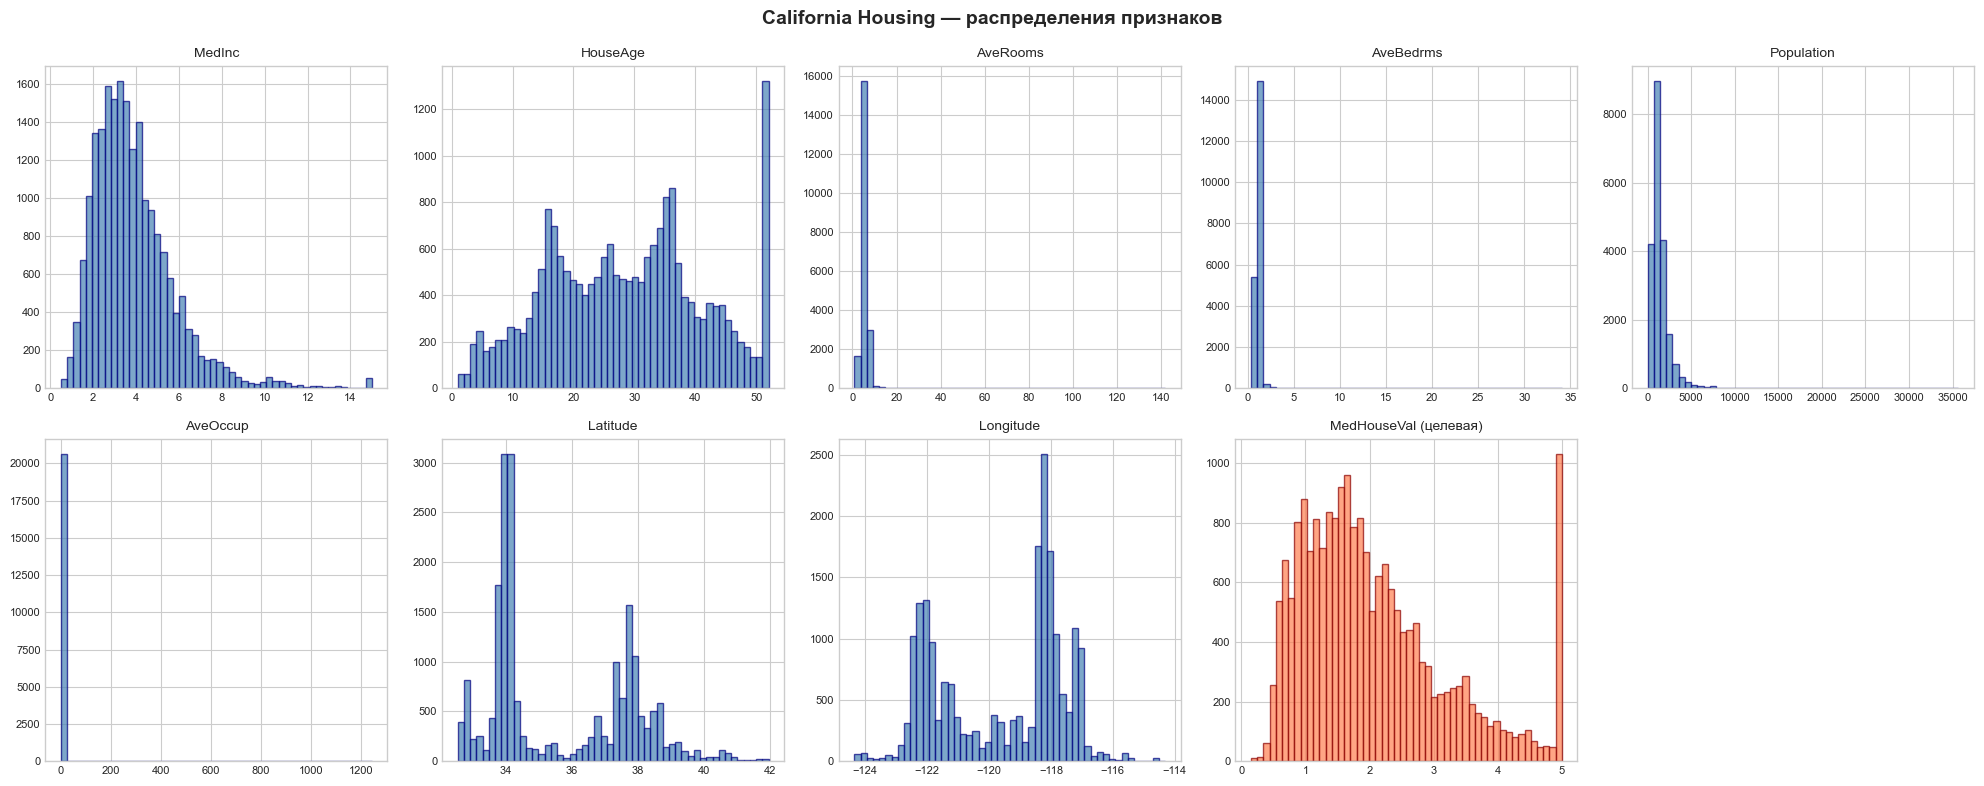

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('California Housing — распределения признаков', fontsize=14, fontweight='bold')

for i, col in enumerate(X_housing.columns):
    ax = axes[i // 5, i % 5]
    ax.hist(X_housing[col], bins=50, color='steelblue', edgecolor='navy', alpha=0.7)
    ax.set_title(col, fontsize=10)
    ax.tick_params(labelsize=8)

ax = axes[1, 3]
ax.hist(y_housing, bins=50, color='coral', edgecolor='darkred', alpha=0.7)
ax.set_title('MedHouseVal (целевая)', fontsize=10)
ax.tick_params(labelsize=8)
axes[1, 4].axis('off')

plt.tight_layout()
plt.show()


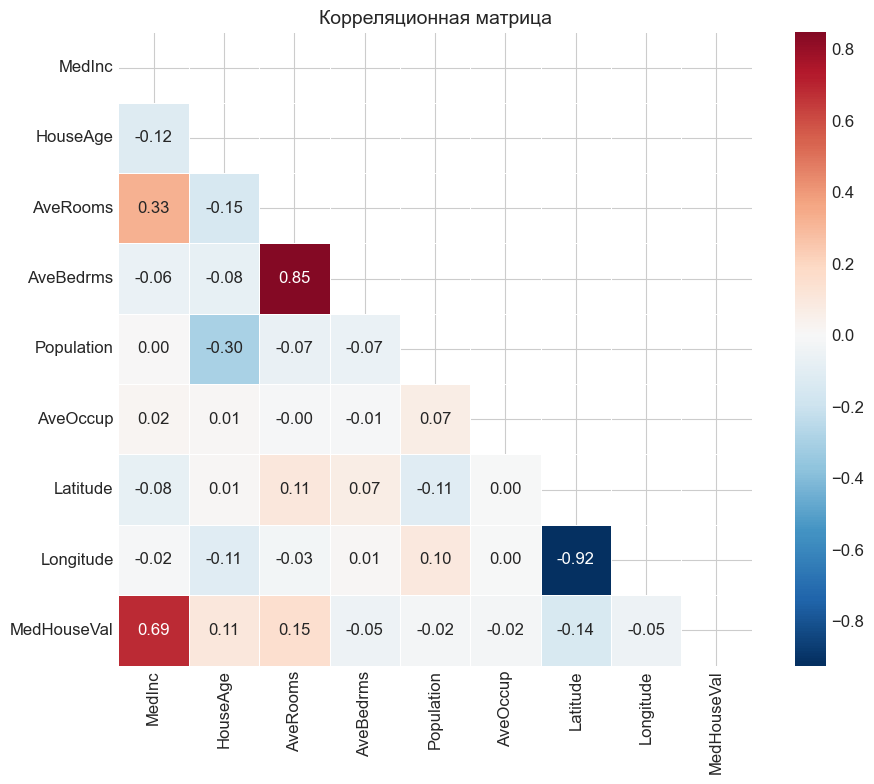

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
full_data = X_housing.copy()
full_data['MedHouseVal'] = y_housing
corr = full_data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Корреляционная матрица', fontsize=14)
plt.tight_layout()
plt.show()


In [6]:
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)
print(f"Обучающая выборка: {X_train_h.shape[0]} объектов")
print(f"Тестовая выборка:  {X_test_h.shape[0]} объектов")


Обучающая выборка: 16512 объектов
Тестовая выборка:  4128 объектов


### Модель 1: дерево без ограничений (baseline)

In [7]:
dt_housing_full = DecisionTreeRegressor(random_state=42)

start_time = time.time()
dt_housing_full.fit(X_train_h, y_train_h)
train_time_full = time.time() - start_time

print(f"Время обучения: {train_time_full*1000:.2f} мс\n")
results_h_full = evaluate_model(dt_housing_full, X_train_h, X_test_h, y_train_h, y_test_h, 
                                 "DT без ограничений (California Housing)")


Время обучения: 133.07 мс

РЕЗУЛЬТАТЫ: DT без ограничений (California Housing)

Метрика                  Обучение         Тест      Разница
--------------------------------------------------------
MSE                        0.0000       0.4952       0.4952
RMSE                       0.0000       0.7037       0.7037
MAE                        0.0000       0.4547       0.4547
R2 Score                   1.0000       0.6221       0.3779

Время предсказания (train): 3.55 мс
Время предсказания (test):  1.09 мс
Глубина дерева: 34
Количество листьев: 15854


**Что видим:** R2 на train = 1.0 — дерево идеально запомнило все обучающие данные (каждый объект попал в свой лист). На test R2 значительно ниже — модель переобучена. Она выучила шум и частные особенности обучающих данных вместо общих закономерностей.

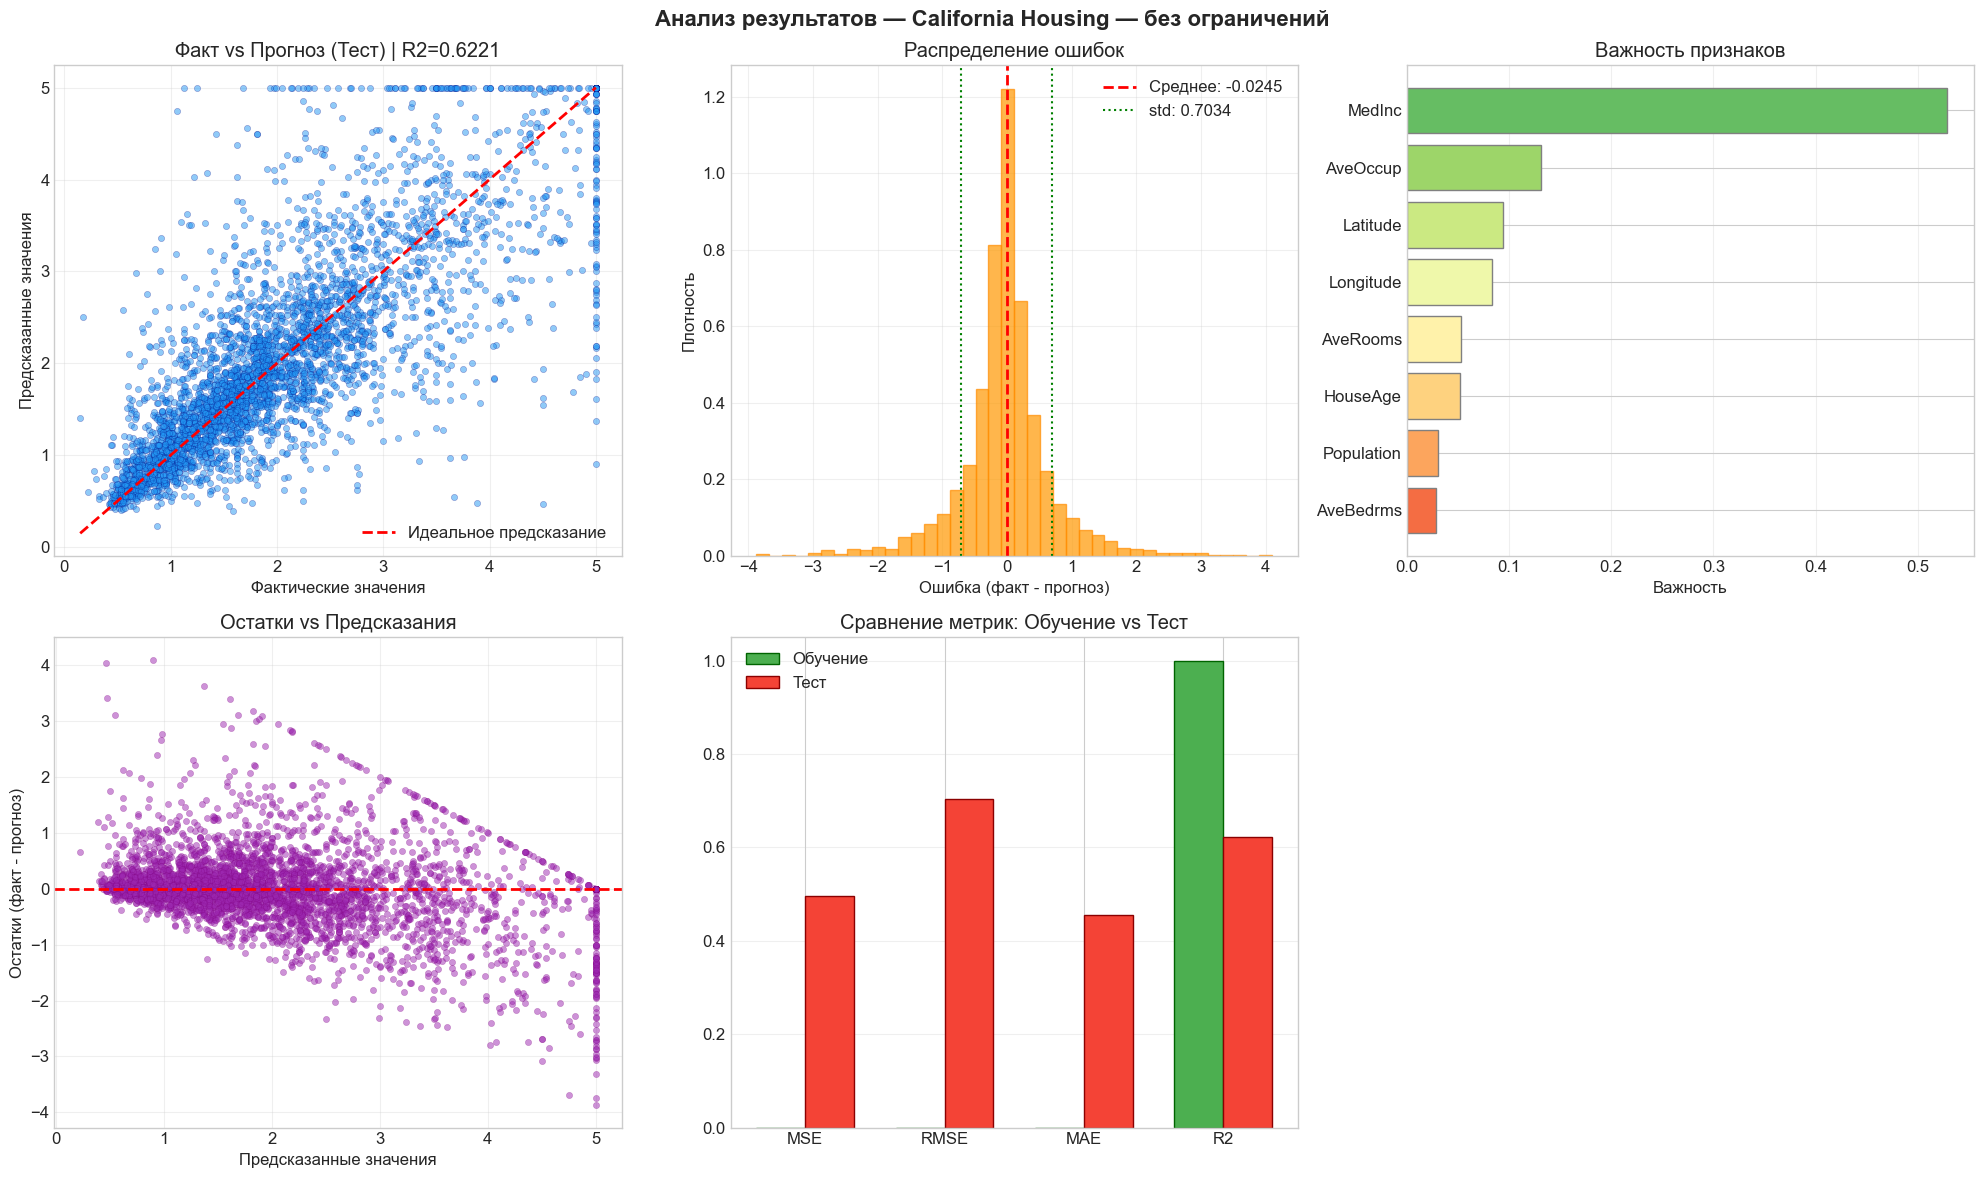

In [8]:
plot_detailed_analysis(dt_housing_full, X_train_h, X_test_h, y_train_h, y_test_h, 
                       results_h_full, housing.feature_names, "California Housing — без ограничений")


### Анализ влияния глубины дерева

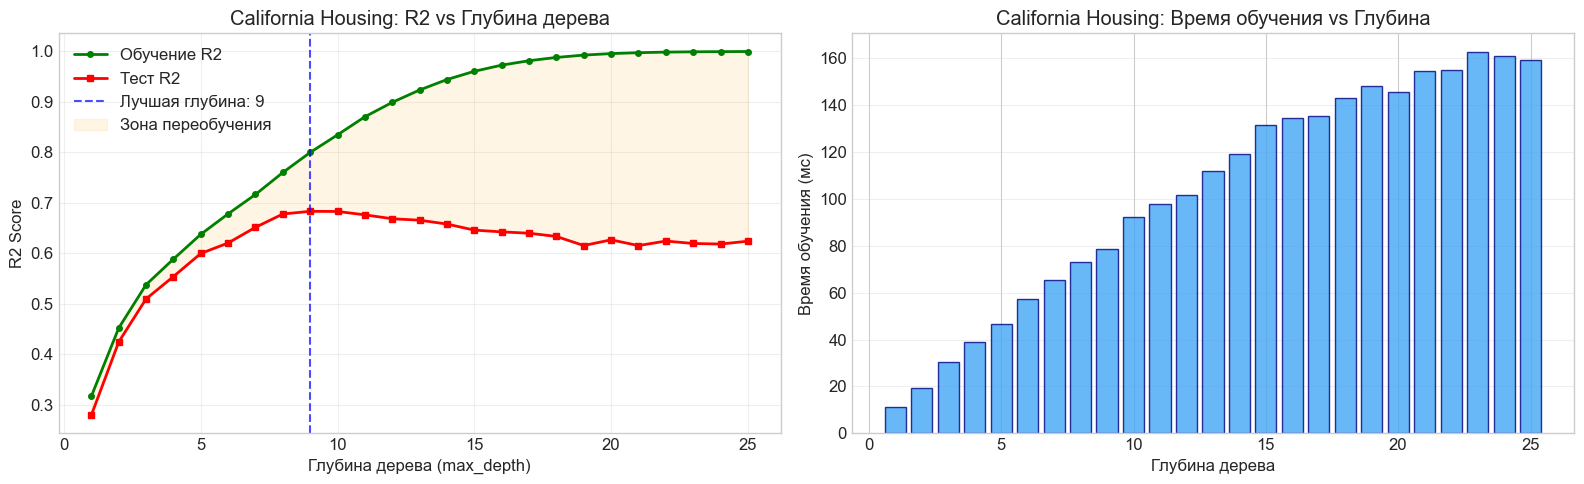

Лучшая глубина по Тест R2: 9 (R2 = 0.6833)


In [9]:
best_depth_h = plot_depth_analysis(X_train_h, X_test_h, y_train_h, y_test_h, "California Housing")


### Модель 2: оптимизированное дерево (GridSearchCV)

Теперь перебираем комбинации нескольких параметров одновременно через GridSearchCV. Он может найти другую оптимальную глубину, потому что подбирает `max_depth` в сочетании с другими параметрами (min_samples_split, min_samples_leaf, max_features), и оценивает через 5-fold кросс-валидацию, а не по одному фиксированному разбиению.

In [10]:
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10, 20],
    'max_features': ['sqrt', 'log2', None],
}

grid_search_h = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid, cv=5, scoring='r2', n_jobs=-1
)

start_time = time.time()
grid_search_h.fit(X_train_h, y_train_h)
grid_time_h = time.time() - start_time

print(f"Время GridSearchCV: {grid_time_h:.2f} сек")
print(f"Лучшие параметры: {grid_search_h.best_params_}")
print(f"Лучший CV R2: {grid_search_h.best_score_:.4f}")


Время GridSearchCV: 11.66 сек
Лучшие параметры: {'max_depth': 15, 'max_features': None, 'min_samples_leaf': 20, 'min_samples_split': 2}
Лучший CV R2: 0.7243


In [11]:
dt_housing_opt = grid_search_h.best_estimator_
results_h_opt = evaluate_model(dt_housing_opt, X_train_h, X_test_h, y_train_h, y_test_h, 
                                "DT оптимизированное (California Housing)")


РЕЗУЛЬТАТЫ: DT оптимизированное (California Housing)

Метрика                  Обучение         Тест      Разница
--------------------------------------------------------
MSE                        0.2556       0.3574       0.1019
RMSE                       0.5055       0.5979       0.0923
MAE                        0.3384       0.4041       0.0657
R2 Score                   0.8088       0.7272       0.0816

Время предсказания (train): 2.32 мс
Время предсказания (test):  1.06 мс
Глубина дерева: 15
Количество листьев: 634


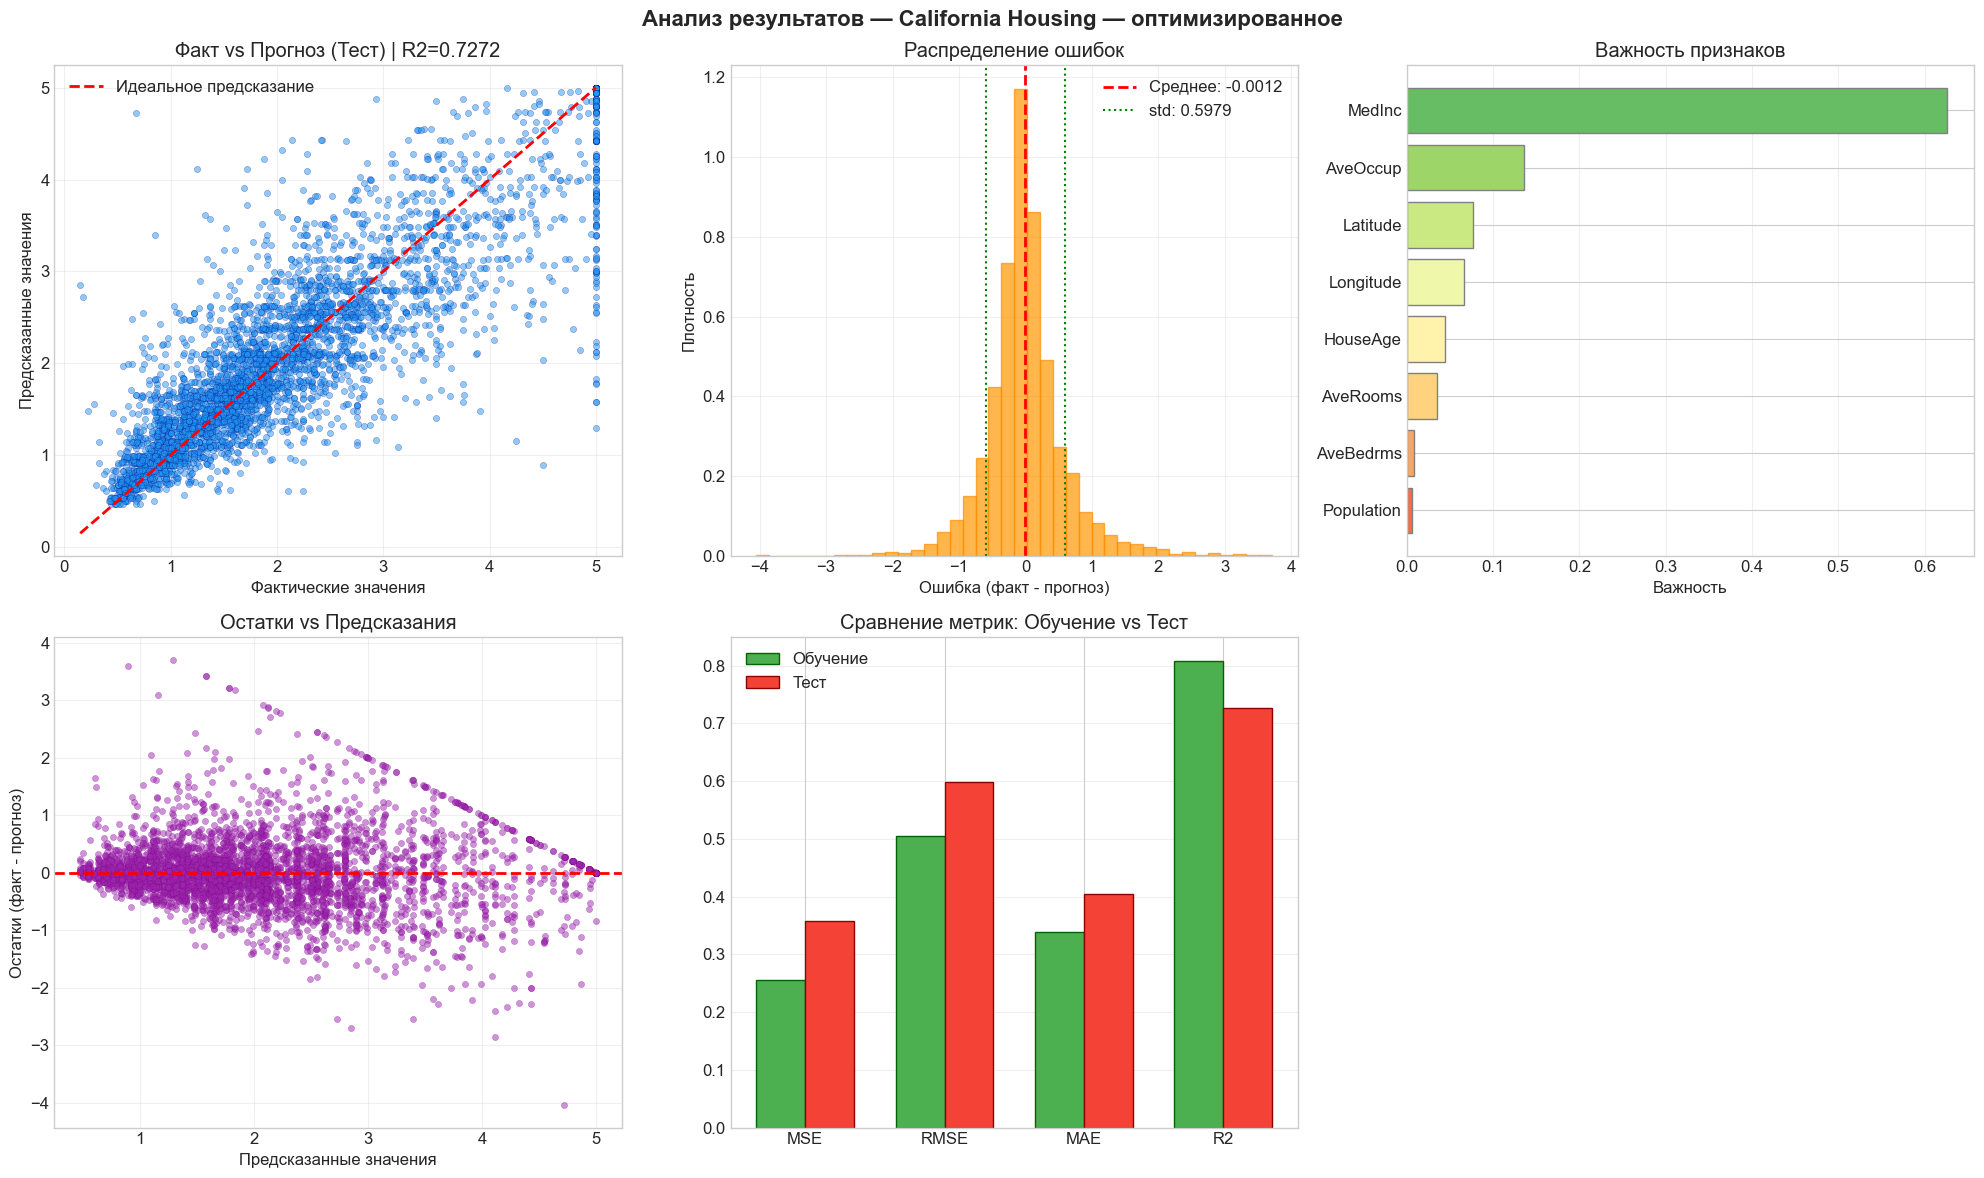

In [12]:
plot_detailed_analysis(dt_housing_opt, X_train_h, X_test_h, y_train_h, y_test_h, 
                       results_h_opt, housing.feature_names, "California Housing — оптимизированное")


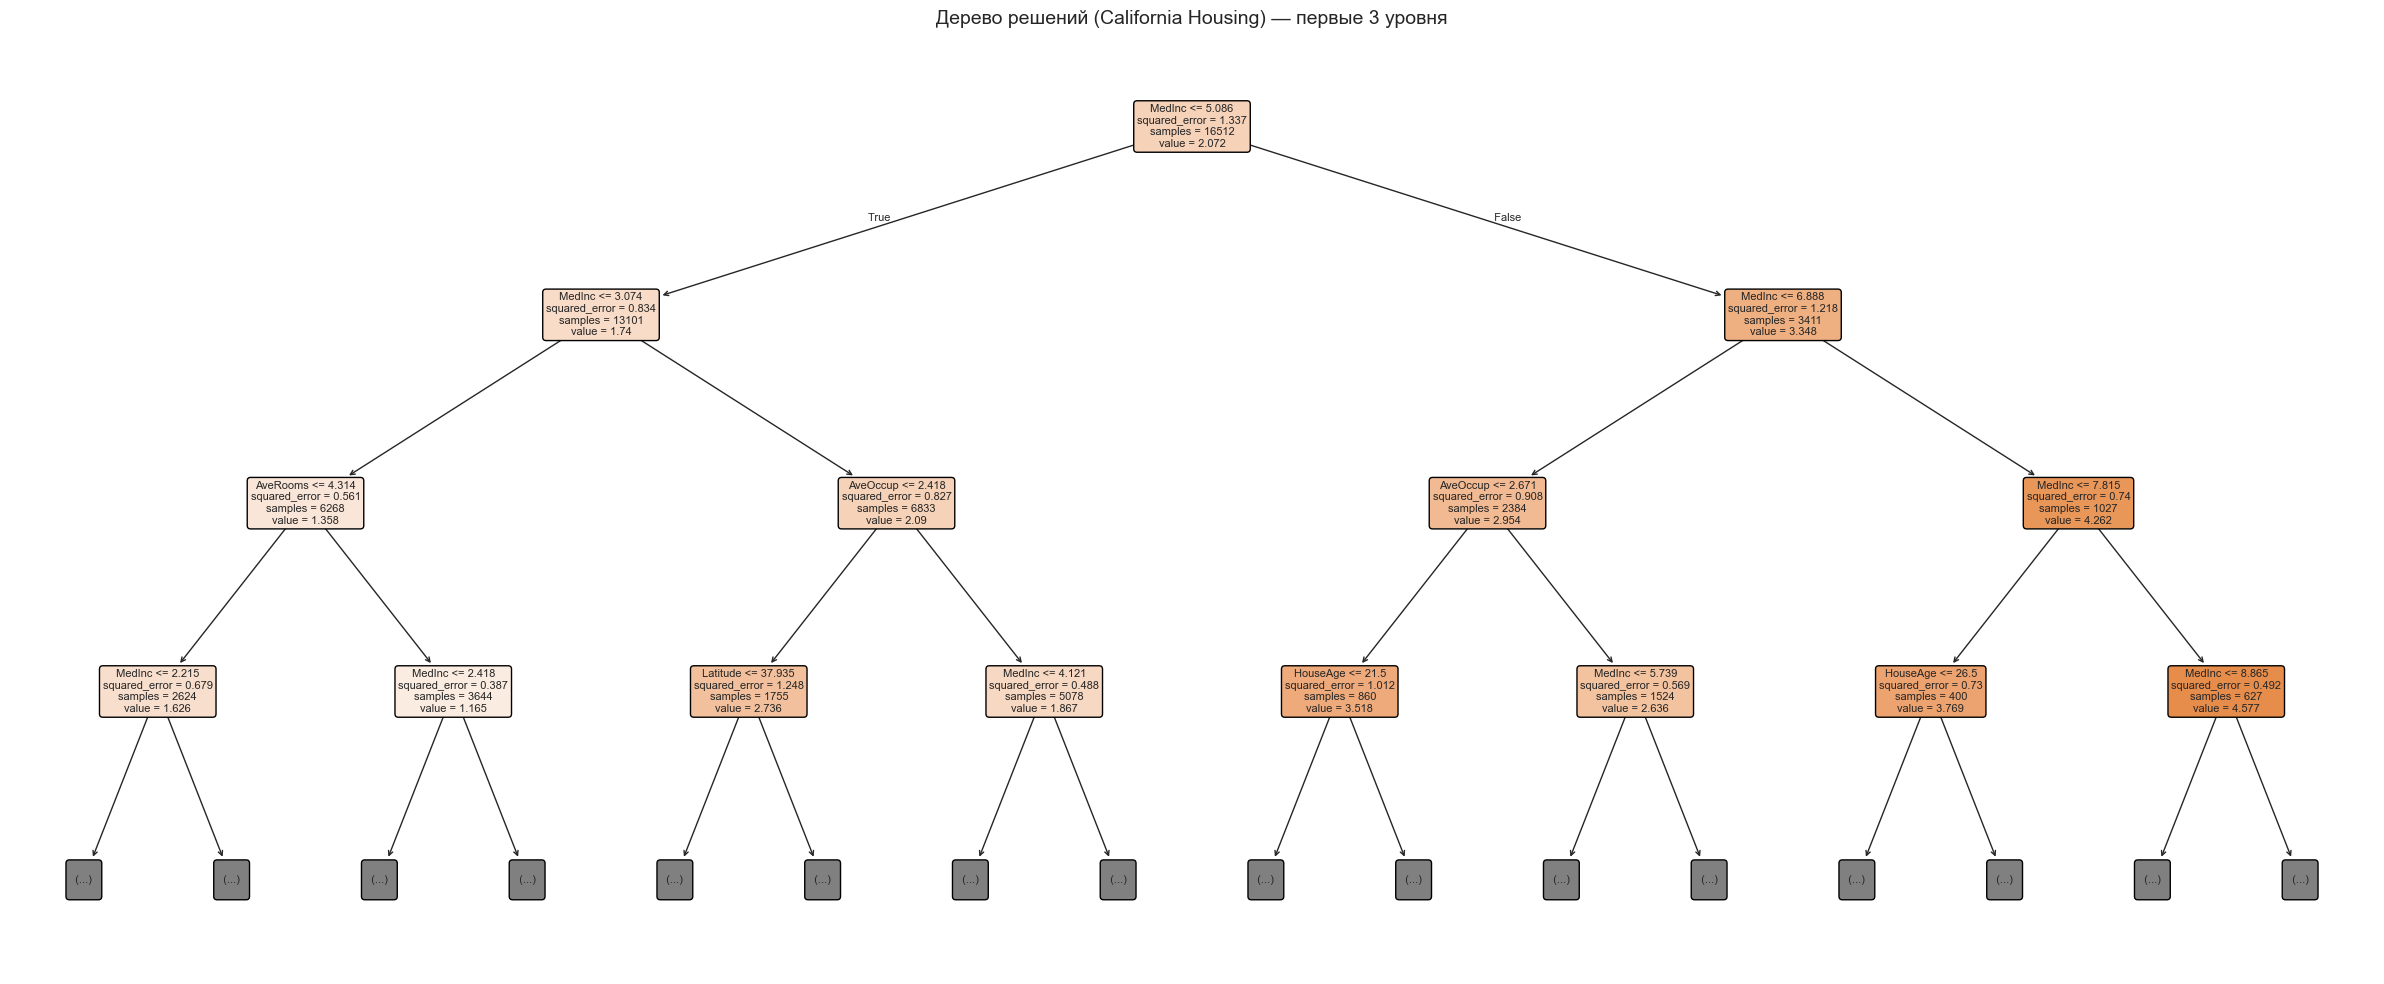

In [13]:
# Визуализация дерева (первые 3 уровня)
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(dt_housing_opt, feature_names=housing.feature_names,
          filled=True, rounded=True, fontsize=8, max_depth=3, ax=ax, impurity=True)
ax.set_title('Дерево решений (California Housing) — первые 3 уровня', fontsize=14)
plt.tight_layout()
plt.show()


### Датасет 2: Diabetes

- **Задача:** предсказание количественного показателя прогрессирования диабета через 1 год
- **Объектов:** 442 — маленький датасет
- **Признаков:** 10 (все заранее нормализованы)
- **Целевая переменная:** мера прогрессирования диабета (чем больше — тем хуже)


|---------|----------------|----------|
| **age** | Возраст | Возраст пациента (нормализован) |
| **sex** | Пол | Пол пациента (бинарный, нормализован) |
| **bmi** | Body Mass Index | Индекс массы тела = вес / рост в квадрате. Норма 18.5-25, выше 30 — ожирение |
| **bp** | Blood Pressure | Среднее артериальное давление |
| **s1** | TC — Total Cholesterol | Общий холестерин в крови |
| **s2** | LDL | «Плохой» холестерин — образует бляшки в сосудах |
| **s3** | HDL | «Хороший» холестерин — очищает сосуды |
| **s4** | TCH — TC/HDL ratio | Отношение общего холестерина к HDL — индекс риска |
| **s5** | LTG — log(Triglycerides) | Логарифм уровня триглицеридов (жиров в крови) |
| **s6** | Glu — Blood Sugar | Уровень глюкозы (сахара) в крови натощак |

Все признаки нормализованы (среднее = 0).

In [14]:
diabetes = load_diabetes()
X_diabetes = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y_diabetes = pd.Series(diabetes.target, name='progression')

print(f"Размер: {X_diabetes.shape[0]} объектов, {X_diabetes.shape[1]} признаков")
print(f"Целевая: диапазон [{y_diabetes.min():.0f}, {y_diabetes.max():.0f}], "
      f"среднее: {y_diabetes.mean():.2f}, std: {y_diabetes.std():.2f}")
print()
display(X_diabetes.head())


Размер: 442 объектов, 10 признаков
Целевая: диапазон [25, 346], среднее: 152.13, std: 77.09



,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.0381,0.0507,0.0617,0.0219,-0.0442,-0.0348,-0.0434,-0.0026,0.0199,-0.0176
1,-0.0019,-0.0446,-0.0515,-0.0263,-0.0084,-0.0192,0.0744,-0.0395,-0.0683,-0.0922
2,0.0853,0.0507,0.0445,-0.0057,-0.0456,-0.0342,-0.0324,-0.0026,0.0029,-0.0259
3,-0.0891,-0.0446,-0.0116,-0.0367,0.0122,0.0250,-0.0360,0.0343,0.0227,-0.0094
4,0.0054,-0.0446,-0.0364,0.0219,0.0039,0.0156,0.0081,-0.0026,-0.0320,-0.0466


In [15]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_diabetes, y_diabetes, test_size=0.2, random_state=42
)
print(f"Обучение: {X_train_d.shape[0]}, Тест: {X_test_d.shape[0]}")


Обучение: 353, Тест: 89


### Модель без ограничений

In [16]:
dt_diabetes_full = DecisionTreeRegressor(random_state=42)

start_time = time.time()
dt_diabetes_full.fit(X_train_d, y_train_d)
print(f"Время обучения: {(time.time()-start_time)*1000:.2f} мс\n")

results_d_full = evaluate_model(dt_diabetes_full, X_train_d, X_test_d, y_train_d, y_test_d,
                                 "DT без ограничений (Diabetes)")


Время обучения: 3.92 мс

РЕЗУЛЬТАТЫ: DT без ограничений (Diabetes)

Метрика                  Обучение         Тест      Разница
--------------------------------------------------------
MSE                        0.0000    4976.7978    4976.7978
RMSE                       0.0000      70.5464      70.5464
MAE                        0.0000      54.5281      54.5281
R2 Score                   1.0000       0.0607       0.9393

Время предсказания (train): 1.06 мс
Время предсказания (test):  0.81 мс
Глубина дерева: 19
Количество листьев: 346


**Что видим:** на маленьком датасете (442 объекта) переобучение особенно сильное. R2(train) = 1.0, а R2(test) может быть отрицательным. Отрицательный R2 означает, что модель предсказывает хуже, чем если бы мы просто всегда отвечали средним значением. При малом количестве данных каждый лист содержит 1-2 объекта, и предсказание по ним получается случайным.

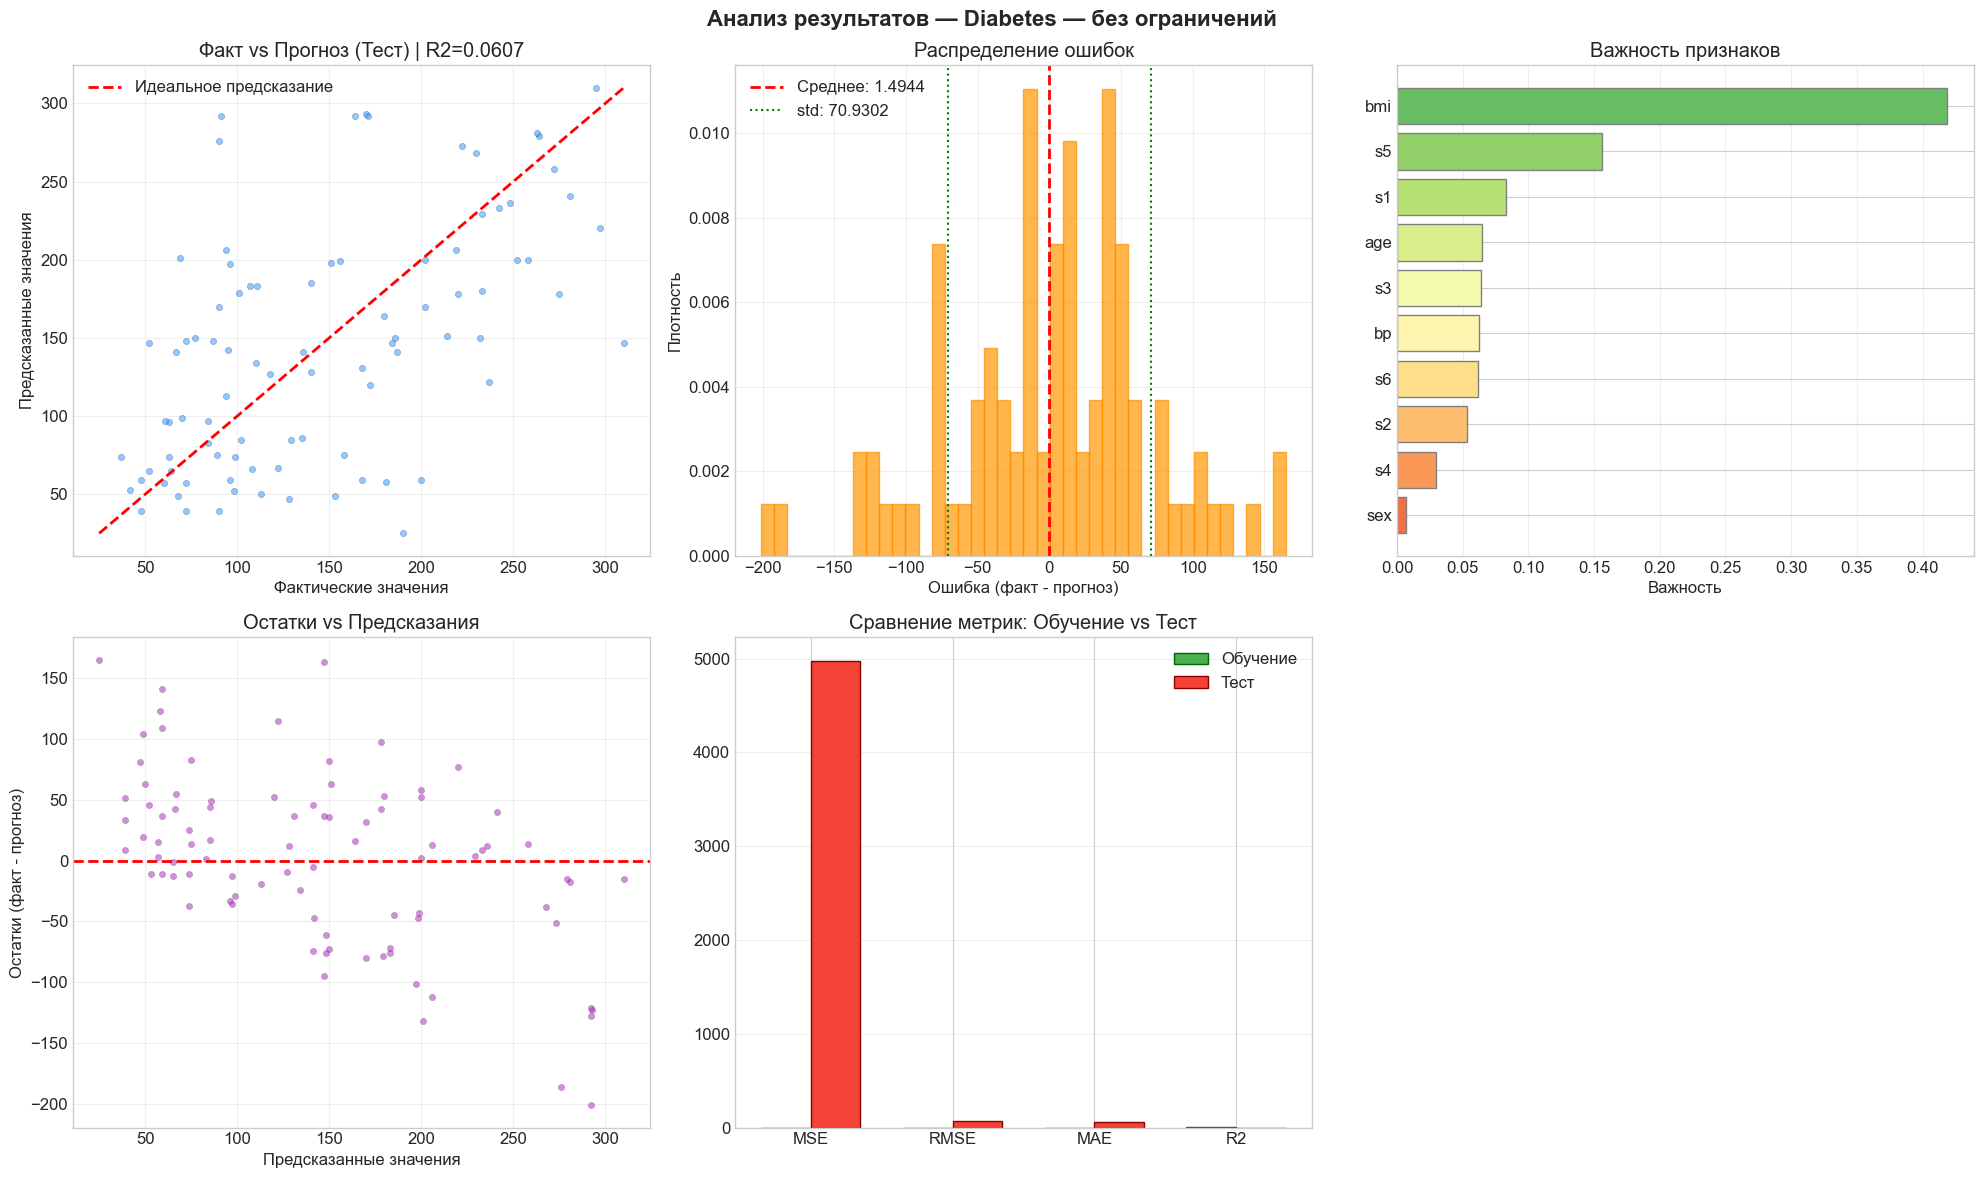

In [17]:
plot_detailed_analysis(dt_diabetes_full, X_train_d, X_test_d, y_train_d, y_test_d, 
                       results_d_full, diabetes.feature_names, "Diabetes — без ограничений")


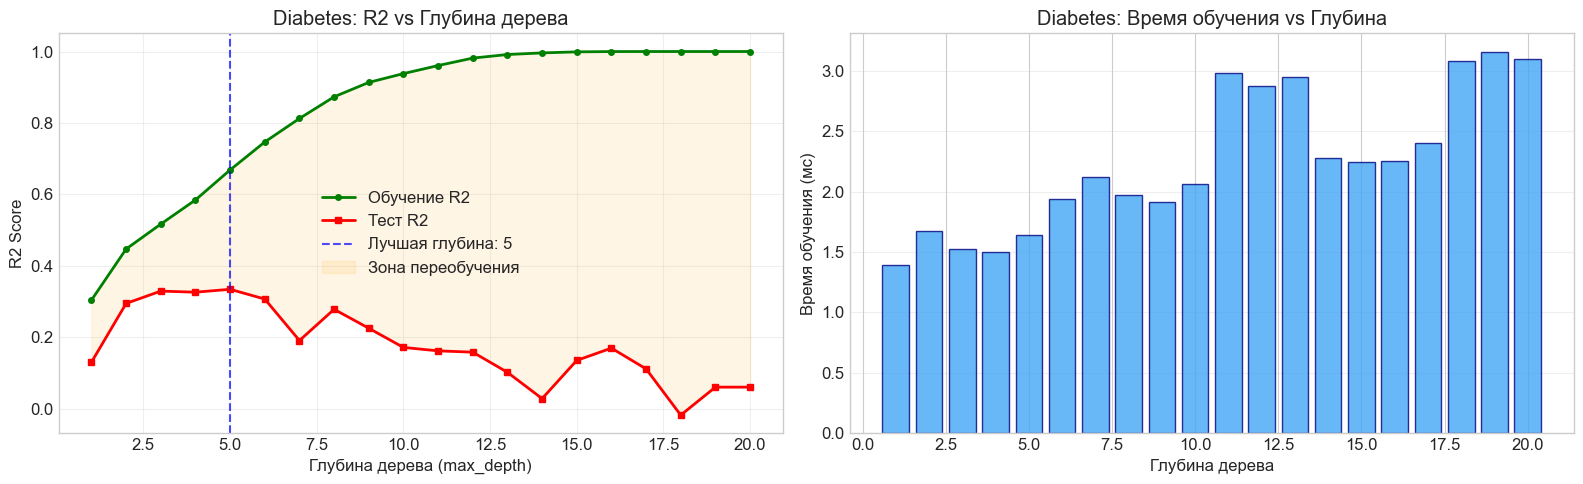

Лучшая глубина по Тест R2: 5 (R2 = 0.3345)


In [18]:
best_depth_d = plot_depth_analysis(X_train_d, X_test_d, y_train_d, y_test_d, "Diabetes", max_d=20)


### Оптимизированное дерево

In [19]:
param_grid_d = {
    'max_depth': [2, 3, 4, 5, 7, 10],
    'min_samples_split': [2, 5, 10, 20, 30],
    'min_samples_leaf': [1, 5, 10, 15, 20],
    'max_features': ['sqrt', 'log2', None],
}

grid_search_d = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid_d, cv=5, scoring='r2', n_jobs=-1
)

start_time = time.time()
grid_search_d.fit(X_train_d, y_train_d)
print(f"Время GridSearchCV: {time.time()-start_time:.2f} сек")
print(f"Лучшие параметры: {grid_search_d.best_params_}")
print(f"Лучший CV R2: {grid_search_d.best_score_:.4f}")


Время GridSearchCV: 1.33 сек
Лучшие параметры: {'max_depth': 2, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Лучший CV R2: 0.3516


In [20]:
dt_diabetes_opt = grid_search_d.best_estimator_
results_d_opt = evaluate_model(dt_diabetes_opt, X_train_d, X_test_d, y_train_d, y_test_d,
                                "DT оптимизированное (Diabetes)")


РЕЗУЛЬТАТЫ: DT оптимизированное (Diabetes)

Метрика                  Обучение         Тест      Разница
--------------------------------------------------------
MSE                     3358.6254    3735.4996     376.8742
RMSE                      57.9536      61.1187       3.1651
MAE                       47.3292      49.3653       2.0362
R2 Score                   0.4473       0.2949       0.1523

Время предсказания (train): 0.88 мс
Время предсказания (test):  0.69 мс
Глубина дерева: 2
Количество листьев: 4


**Что видим:** после оптимизации R2(test) стал положительным, но невысоким (~0.2-0.4). Для 442 объектов это ожидаемый результат — дереву не хватает данных. Самые важные признаки — bmi (индекс массы тела) и s5 (триглицериды), что подтверждается медициной: ожирение и уровень жиров в крови — ключевые факторы прогрессирования диабета.

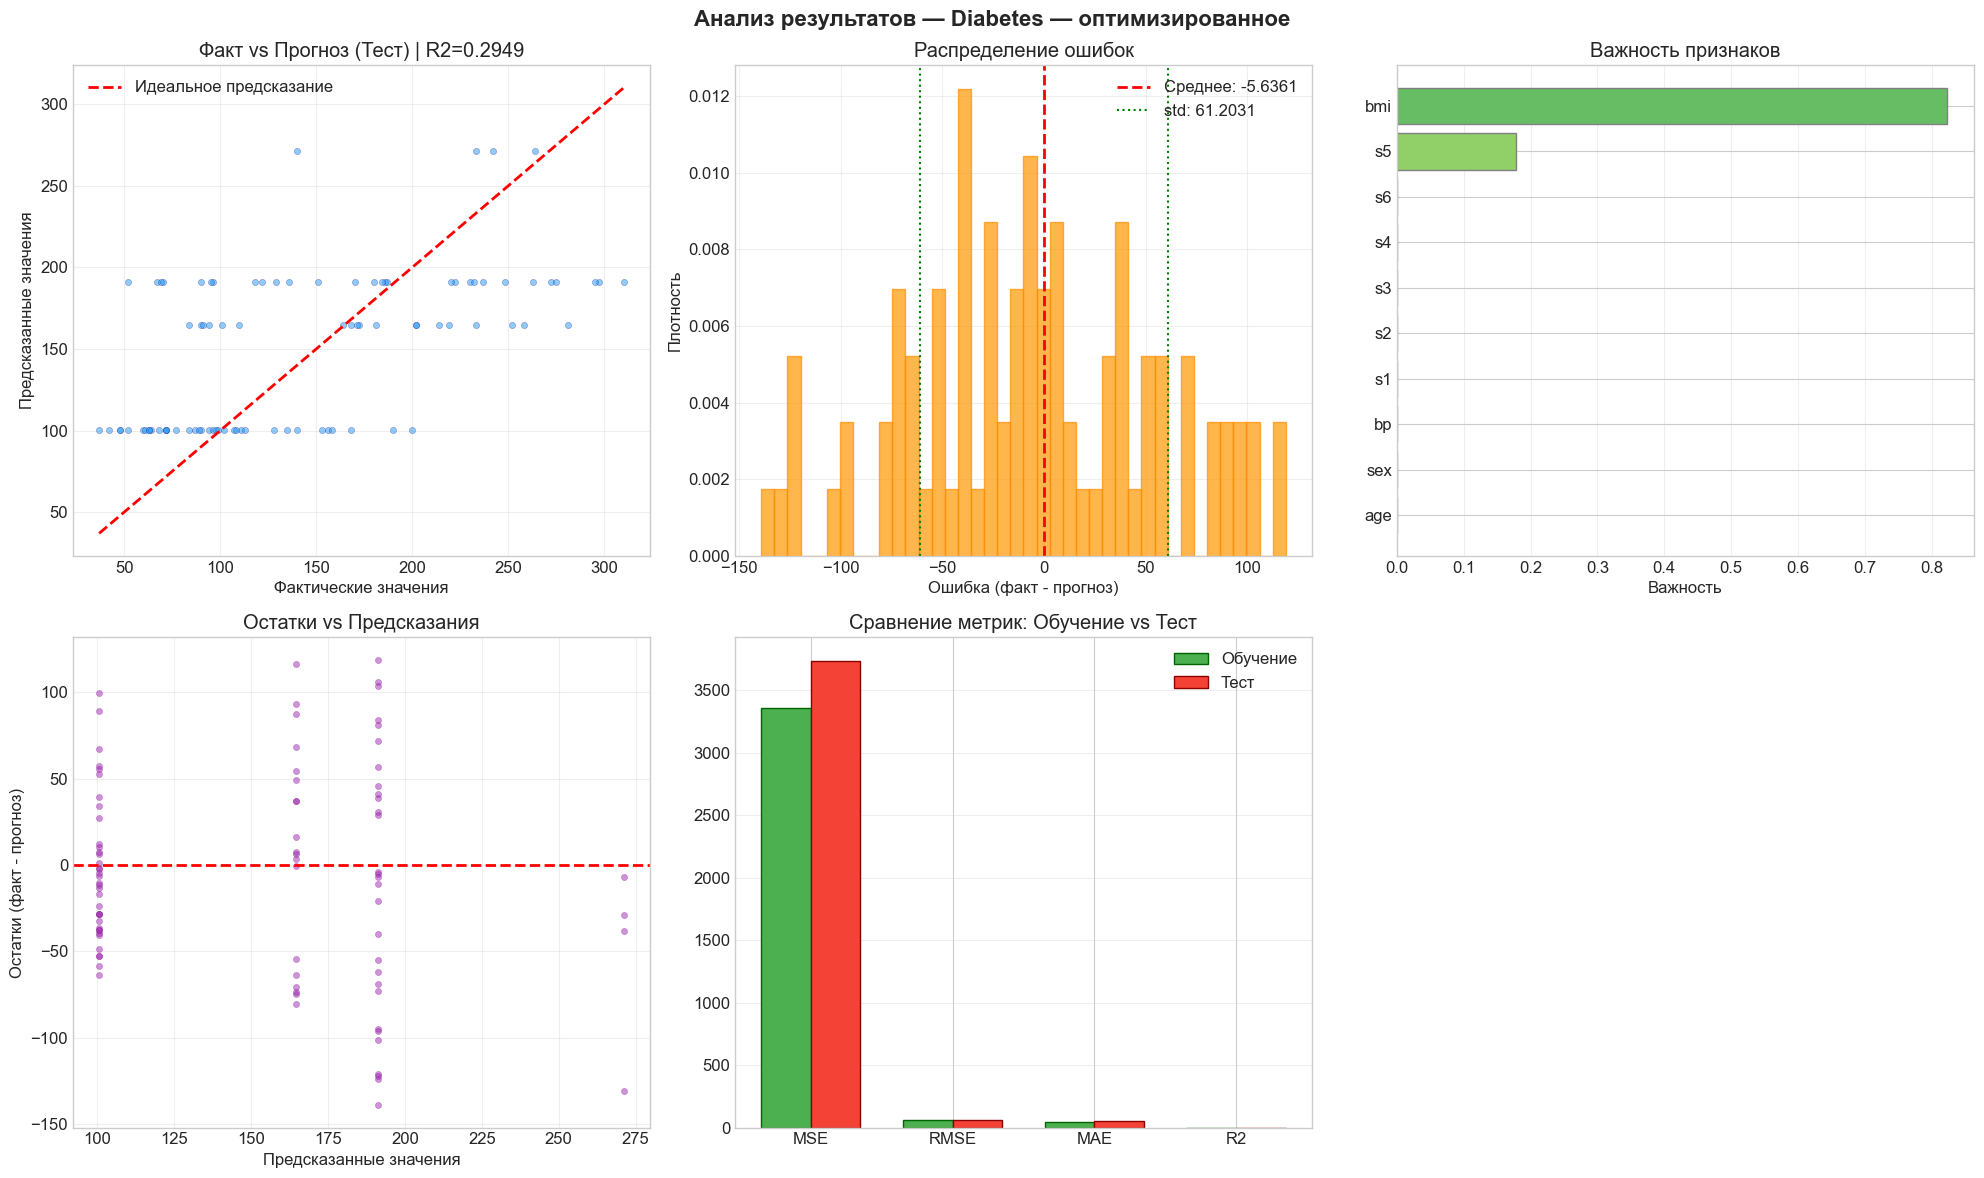

In [21]:
plot_detailed_analysis(dt_diabetes_opt, X_train_d, X_test_d, y_train_d, y_test_d, 
                       results_d_opt, diabetes.feature_names, "Diabetes — оптимизированное")


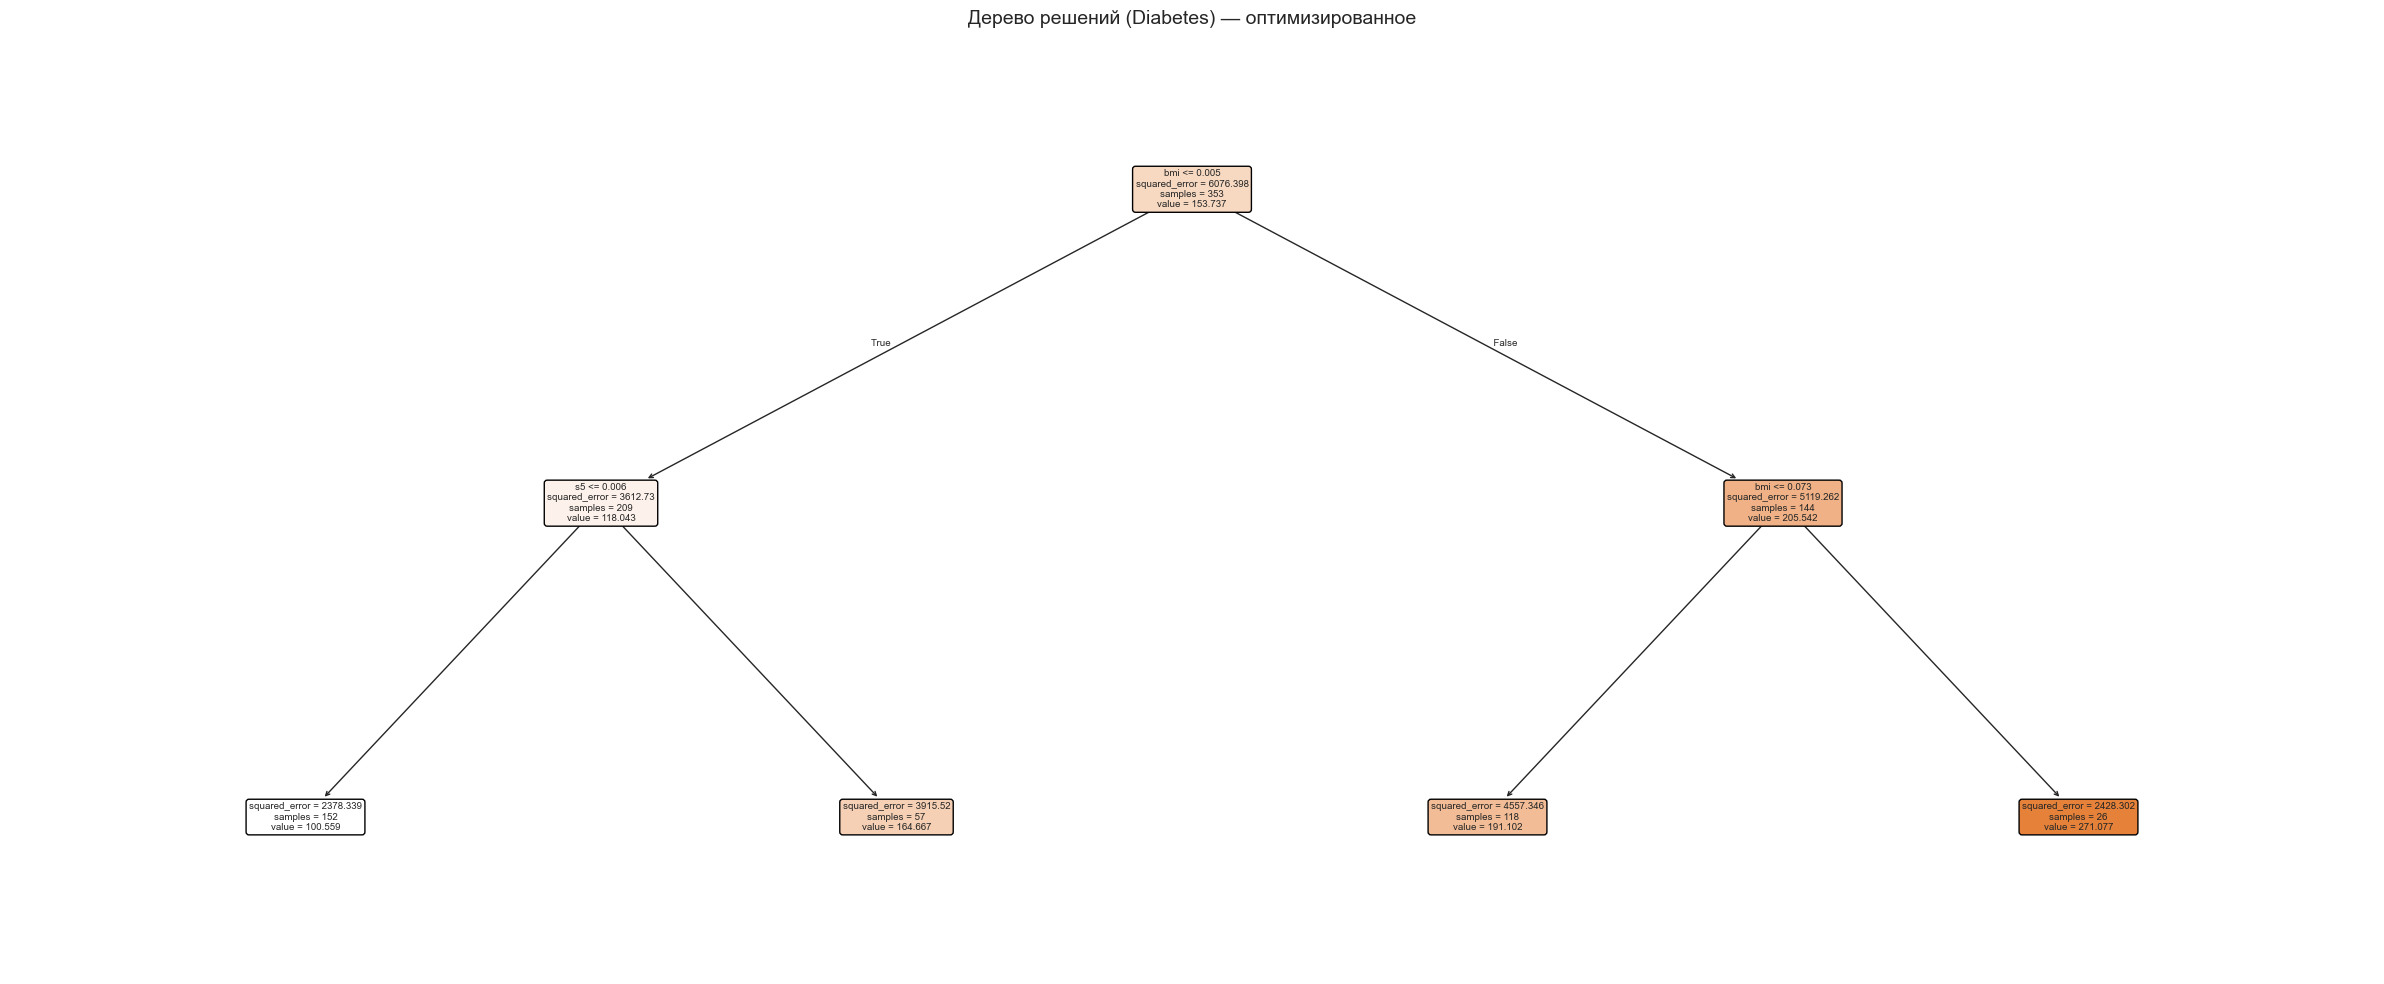

In [22]:
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(dt_diabetes_opt, feature_names=diabetes.feature_names,
          filled=True, rounded=True, fontsize=7, max_depth=4, ax=ax)
ax.set_title('Дерево решений (Diabetes) — оптимизированное', fontsize=14)
plt.tight_layout()
plt.show()


In [23]:
comparison_d = pd.DataFrame({
    'Метрика': ['MSE (Тест)', 'RMSE (Тест)', 'MAE (Тест)', 'R2 (Тест)', 'R2 (Обучение)',
                'Глубина', 'Листьев', 'Переобучение (delta R2)'],
    'Без ограничений': [
        f"{results_d_full['test_mse']:.4f}", f"{results_d_full['test_rmse']:.4f}",
        f"{results_d_full['test_mae']:.4f}", f"{results_d_full['test_r2']:.4f}",
        f"{results_d_full['train_r2']:.4f}", results_d_full['depth'], results_d_full['n_leaves'],
        f"{results_d_full['train_r2'] - results_d_full['test_r2']:.4f}"
    ],
    'Оптимизированное': [
        f"{results_d_opt['test_mse']:.4f}", f"{results_d_opt['test_rmse']:.4f}",
        f"{results_d_opt['test_mae']:.4f}", f"{results_d_opt['test_r2']:.4f}",
        f"{results_d_opt['train_r2']:.4f}", results_d_opt['depth'], results_d_opt['n_leaves'],
        f"{results_d_opt['train_r2'] - results_d_opt['test_r2']:.4f}"
    ]
})
display(comparison_d)


,Метрика,Без ограничений,Оптимизированное
0,MSE (Тест),4976.7978,3735.4996
1,RMSE (Тест),70.5464,61.1187
2,MAE (Тест),54.5281,49.3653
3,R2 (Тест),0.0607,0.2949
4,R2 (Обучение),1.0000,0.4473
5,Глубина,19,2
6,Листьев,346,4
7,Переобучение (delta R2),0.9393,0.1523


### Датасет 3: sin(x)

Создадим максимально простой датасет: **один признак x** и известная функция **y = 3 sin(x) + шум**. Это позволит наглядно увидеть, как именно дерево решений строит свои предсказания — ступеньками.

### Формула

$$y = 3 \cdot \sin(x) + \varepsilon, \quad \varepsilon \sim N(0,\; 0.3)$$

In [24]:
np.random.seed(42)
n_samples = 1000

x = np.random.uniform(-2 * np.pi, 2 * np.pi, n_samples)
noise = np.random.normal(0, 0.3, n_samples)
y_synth = 3 * np.sin(x) + noise

# Для sklearn нужен 2D массив признаков, даже если признак один
X_synth_df = pd.DataFrame({'x': x})
y_synth_series = pd.Series(y_synth, name='target')

print(f"Размер: {X_synth_df.shape[0]} объектов, {X_synth_df.shape[1]} признак")
print(f"Целевая: диапазон [{y_synth.min():.2f}, {y_synth.max():.2f}], "
      f"среднее: {y_synth.mean():.4f}, std: {y_synth.std():.4f}")


Размер: 1000 объектов, 1 признак
Целевая: диапазон [-3.70, 3.60], среднее: 0.1147, std: 2.2003


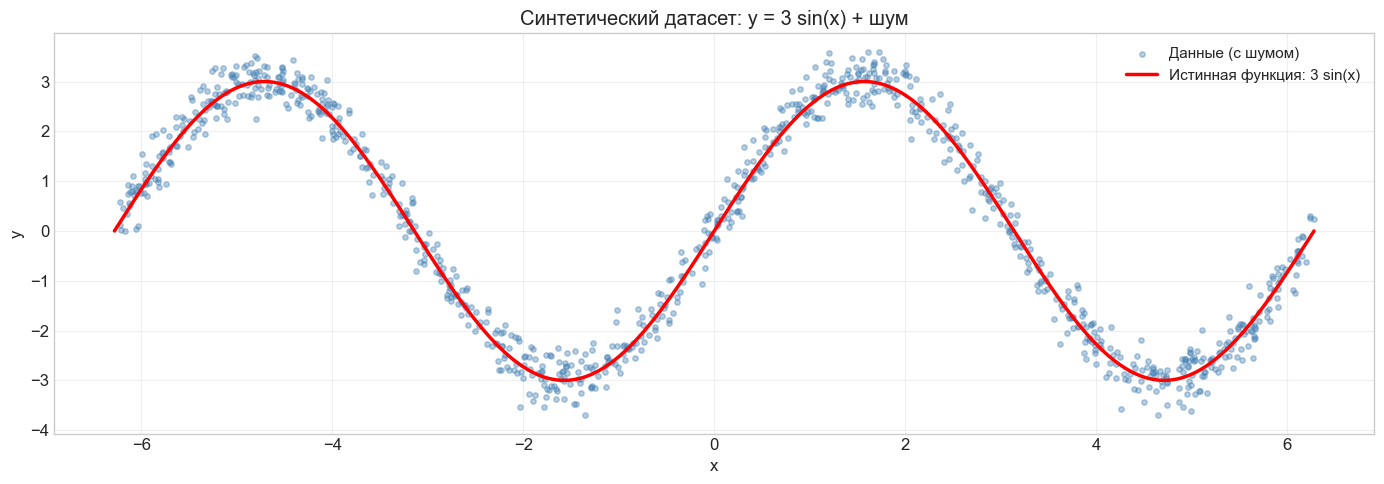

In [25]:
# Визуализация: данные и истинная функция
fig, ax = plt.subplots(figsize=(14, 5))

ax.scatter(x, y_synth, alpha=0.4, s=15, color='steelblue', label='Данные (с шумом)')
x_line = np.linspace(-2*np.pi, 2*np.pi, 500)
ax.plot(x_line, 3 * np.sin(x_line), 'r-', linewidth=2.5, label='Истинная функция: 3 sin(x)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Синтетический датасет: y = 3 sin(x) + шум')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [26]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_synth_df, y_synth_series, test_size=0.2, random_state=42
)
print(f"Обучение: {X_train_s.shape[0]}, Тест: {X_test_s.shape[0]}")


Обучение: 800, Тест: 200


### Модель без ограничений

In [27]:
dt_synth_full = DecisionTreeRegressor(random_state=42)

start_time = time.time()
dt_synth_full.fit(X_train_s, y_train_s)
print(f"Время обучения: {(time.time()-start_time)*1000:.2f} мс\n")

results_s_full = evaluate_model(dt_synth_full, X_train_s, X_test_s, y_train_s, y_test_s,
                                 "DT без ограничений (Synthetic)")


Время обучения: 1.86 мс

РЕЗУЛЬТАТЫ: DT без ограничений (Synthetic)

Метрика                  Обучение         Тест      Разница
--------------------------------------------------------
MSE                        0.0000       0.1869       0.1869
RMSE                       0.0000       0.4323       0.4323
MAE                        0.0000       0.3412       0.3412
R2 Score                   1.0000       0.9608       0.0392

Время предсказания (train): 0.57 мс
Время предсказания (test):  0.40 мс
Глубина дерева: 23
Количество листьев: 800


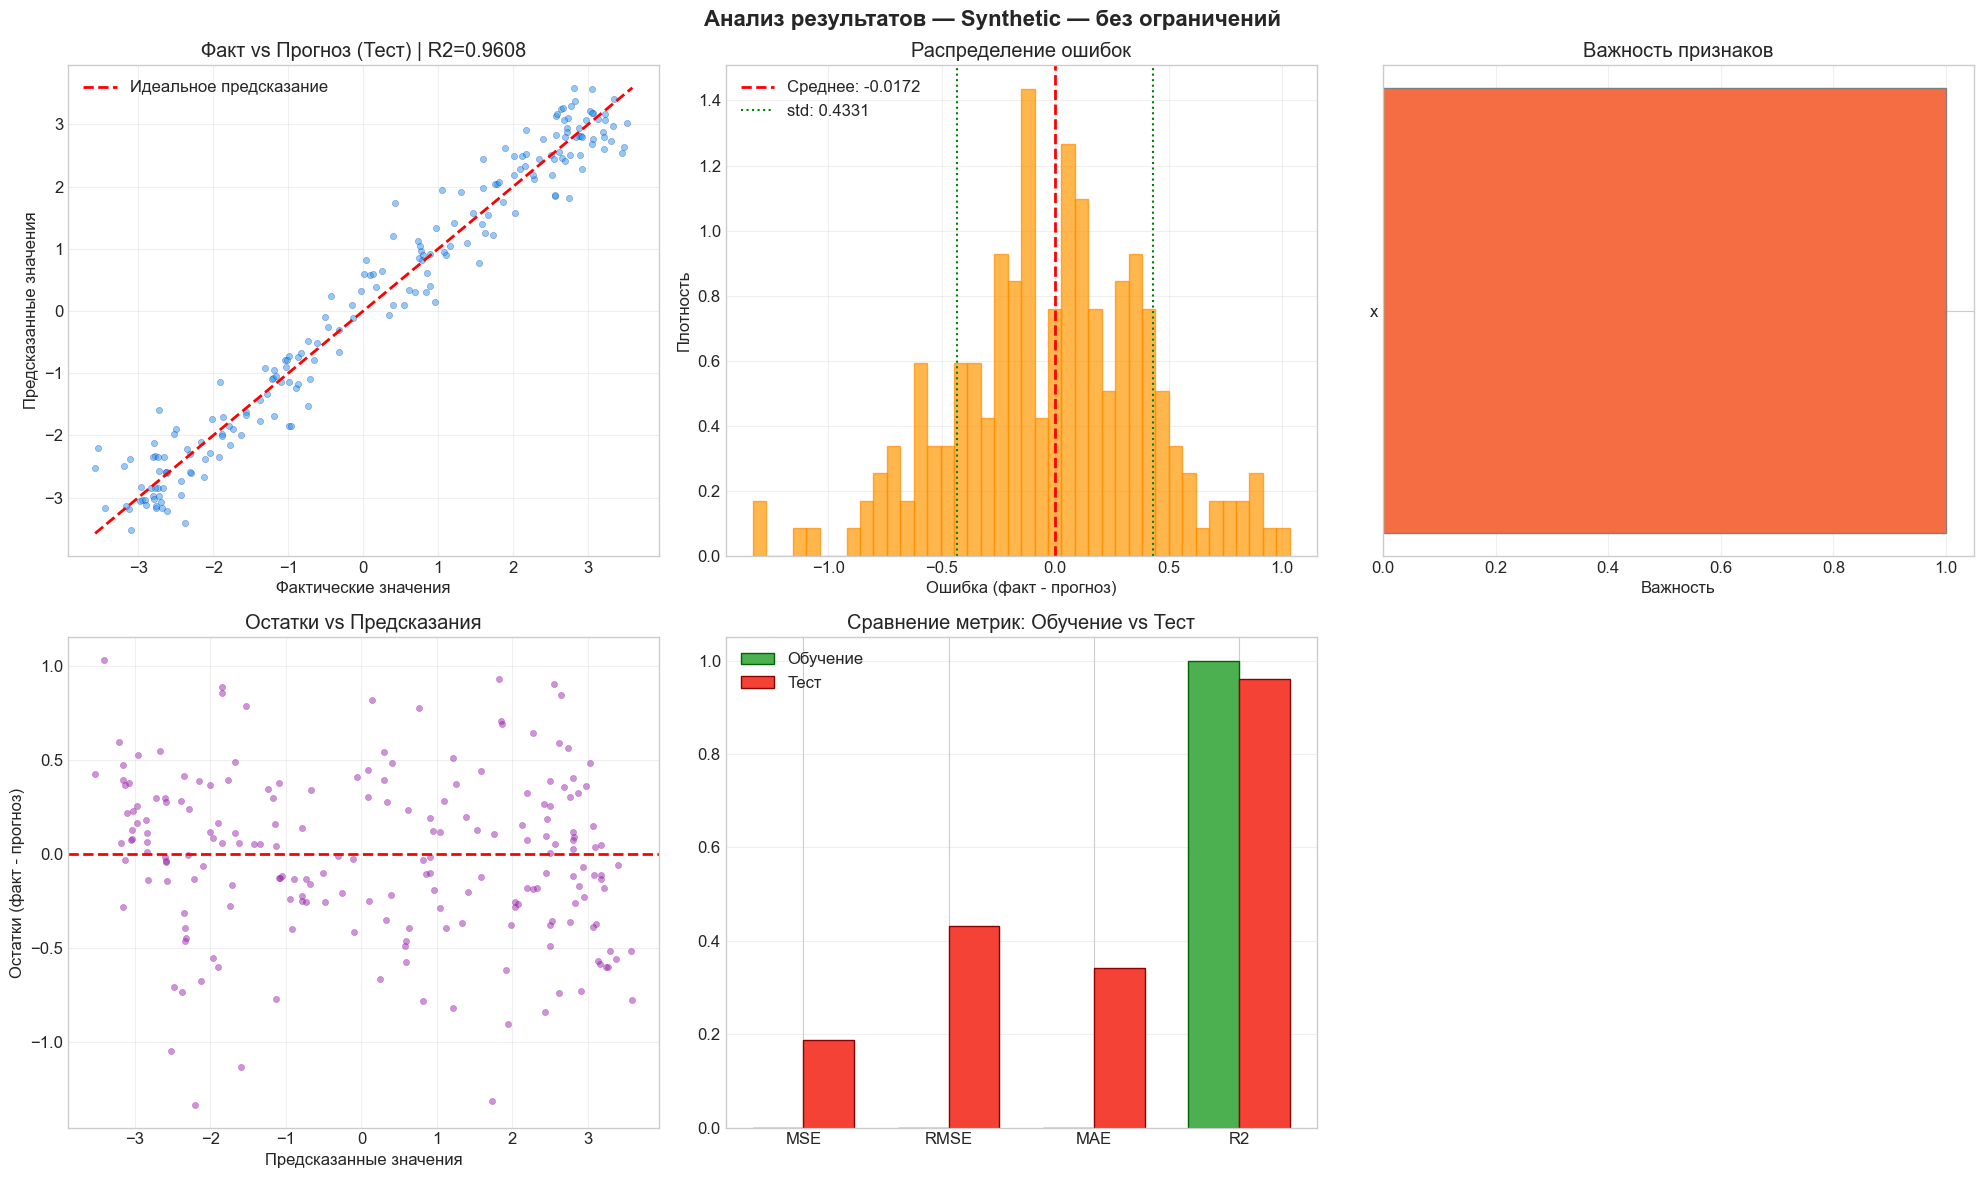

In [28]:
plot_detailed_analysis(dt_synth_full, X_train_s, X_test_s, y_train_s, y_test_s, 
                       results_s_full, ['x'], "Synthetic — без ограничений")


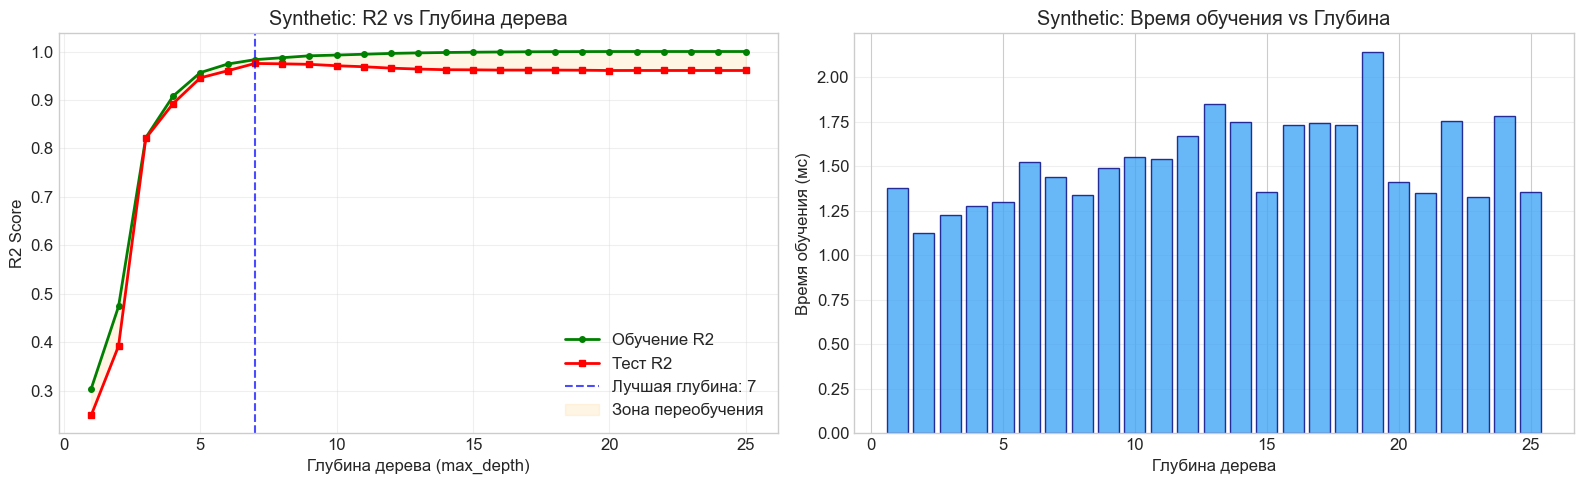

Лучшая глубина по Тест R2: 7 (R2 = 0.9753)


In [29]:
best_depth_s = plot_depth_analysis(X_train_s, X_test_s, y_train_s, y_test_s, "Synthetic", max_d=25)


### Оптимизированное дерево

In [30]:
param_grid_s = {
    'max_depth': [3, 5, 7, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10, 20],
}

grid_search_s = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid_s, cv=5, scoring='r2', n_jobs=-1
)

start_time = time.time()
grid_search_s.fit(X_train_s, y_train_s)
print(f"Время GridSearchCV: {time.time()-start_time:.2f} сек")
print(f"Лучшие параметры: {grid_search_s.best_params_}")
print(f"Лучший CV R2: {grid_search_s.best_score_:.4f}")


Время GridSearchCV: 0.24 сек
Лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}
Лучший CV R2: 0.9748


In [31]:
dt_synth_opt = grid_search_s.best_estimator_
results_s_opt = evaluate_model(dt_synth_opt, X_train_s, X_test_s, y_train_s, y_test_s,
                                "DT оптимизированное (Synthetic)")


РЕЗУЛЬТАТЫ: DT оптимизированное (Synthetic)

Метрика                  Обучение         Тест      Разница
--------------------------------------------------------
MSE                        0.0649       0.1043       0.0393
RMSE                       0.2548       0.3229       0.0681
MAE                        0.2050       0.2562       0.0512
R2 Score                   0.9866       0.9782       0.0085

Время предсказания (train): 0.80 мс
Время предсказания (test):  0.48 мс
Глубина дерева: 10
Количество листьев: 101


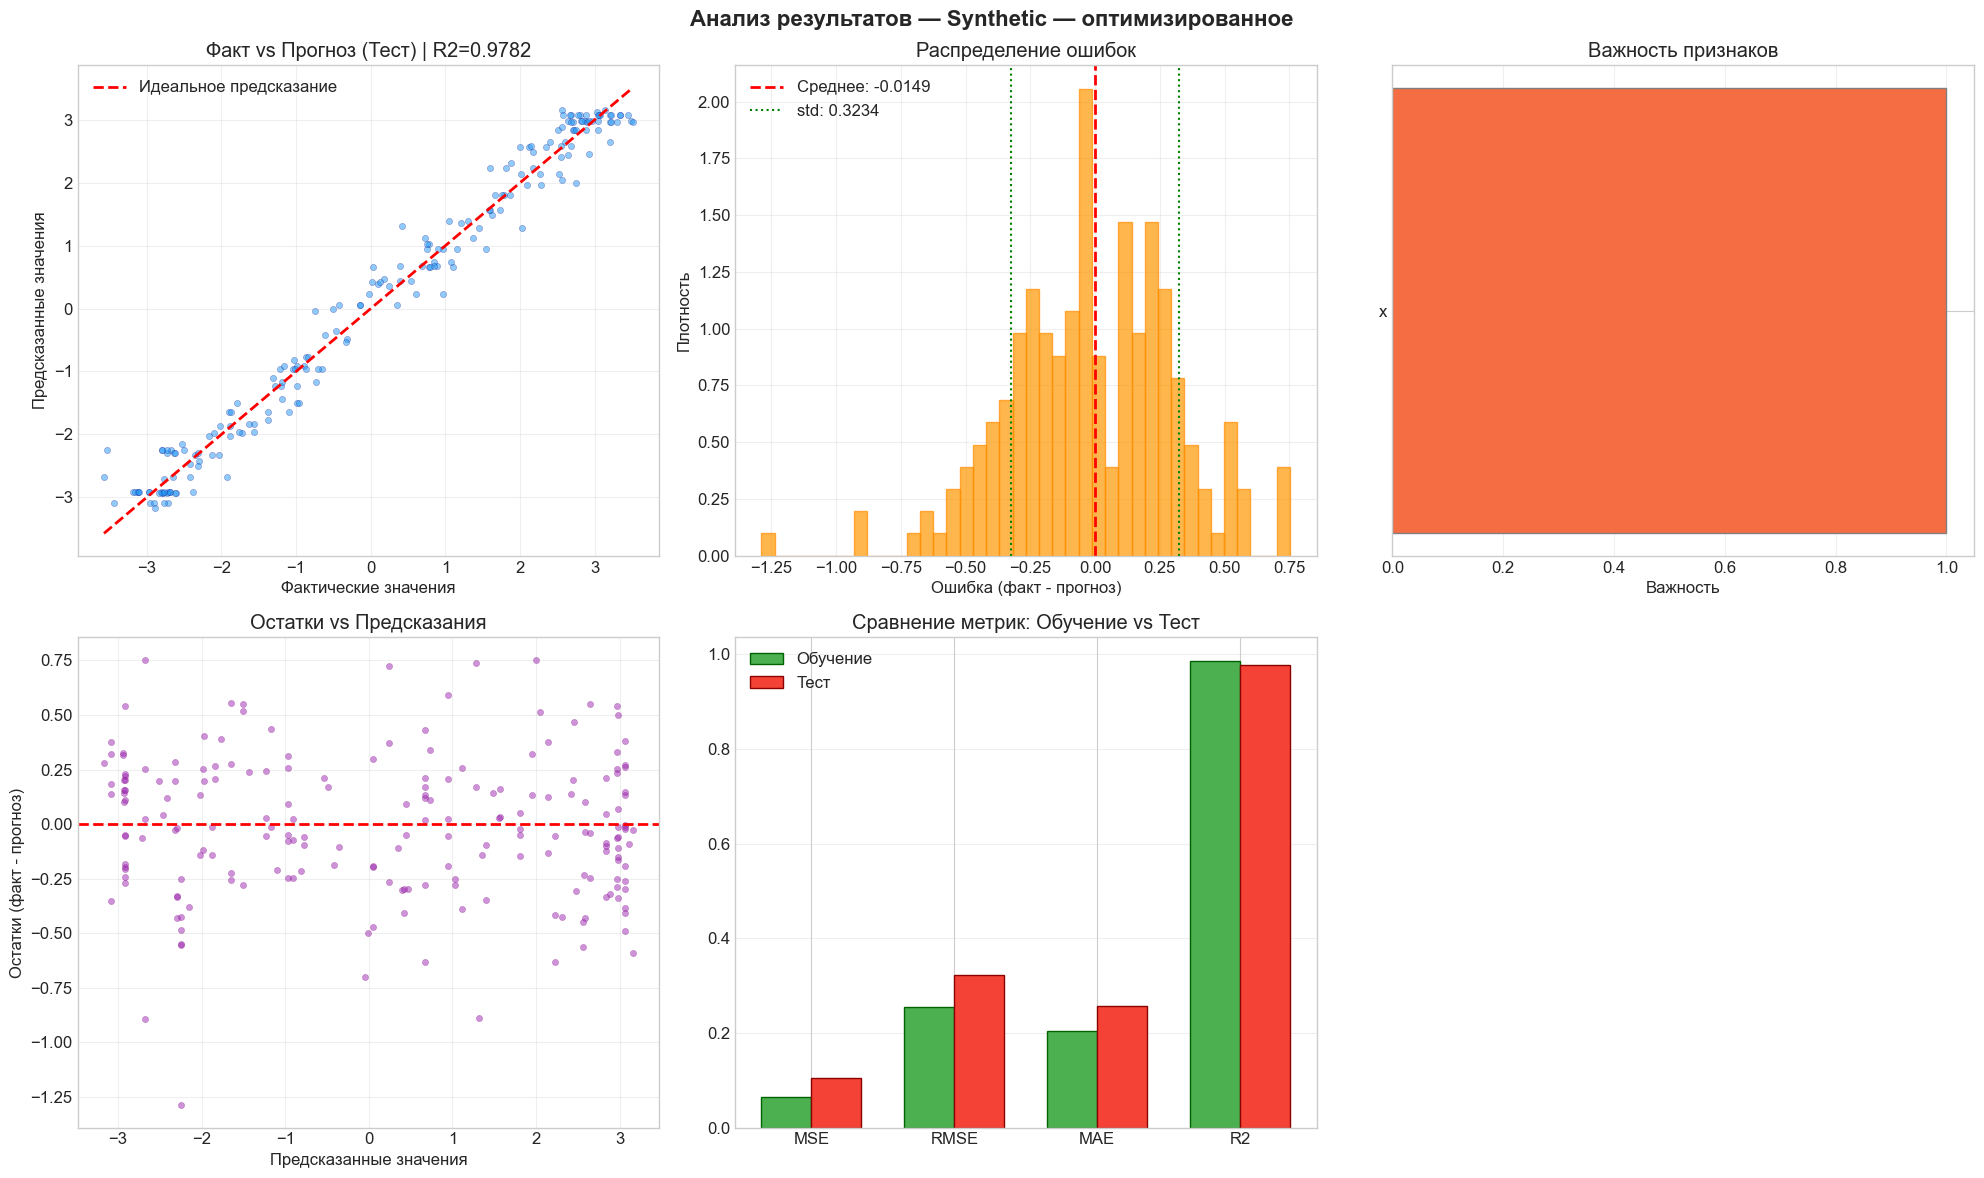

In [32]:
plot_detailed_analysis(dt_synth_opt, X_train_s, X_test_s, y_train_s, y_test_s, 
                       results_s_opt, ['x'], "Synthetic — оптимизированное")


### Как дерево аппроксимирует синусоиду — визуализация по глубинам

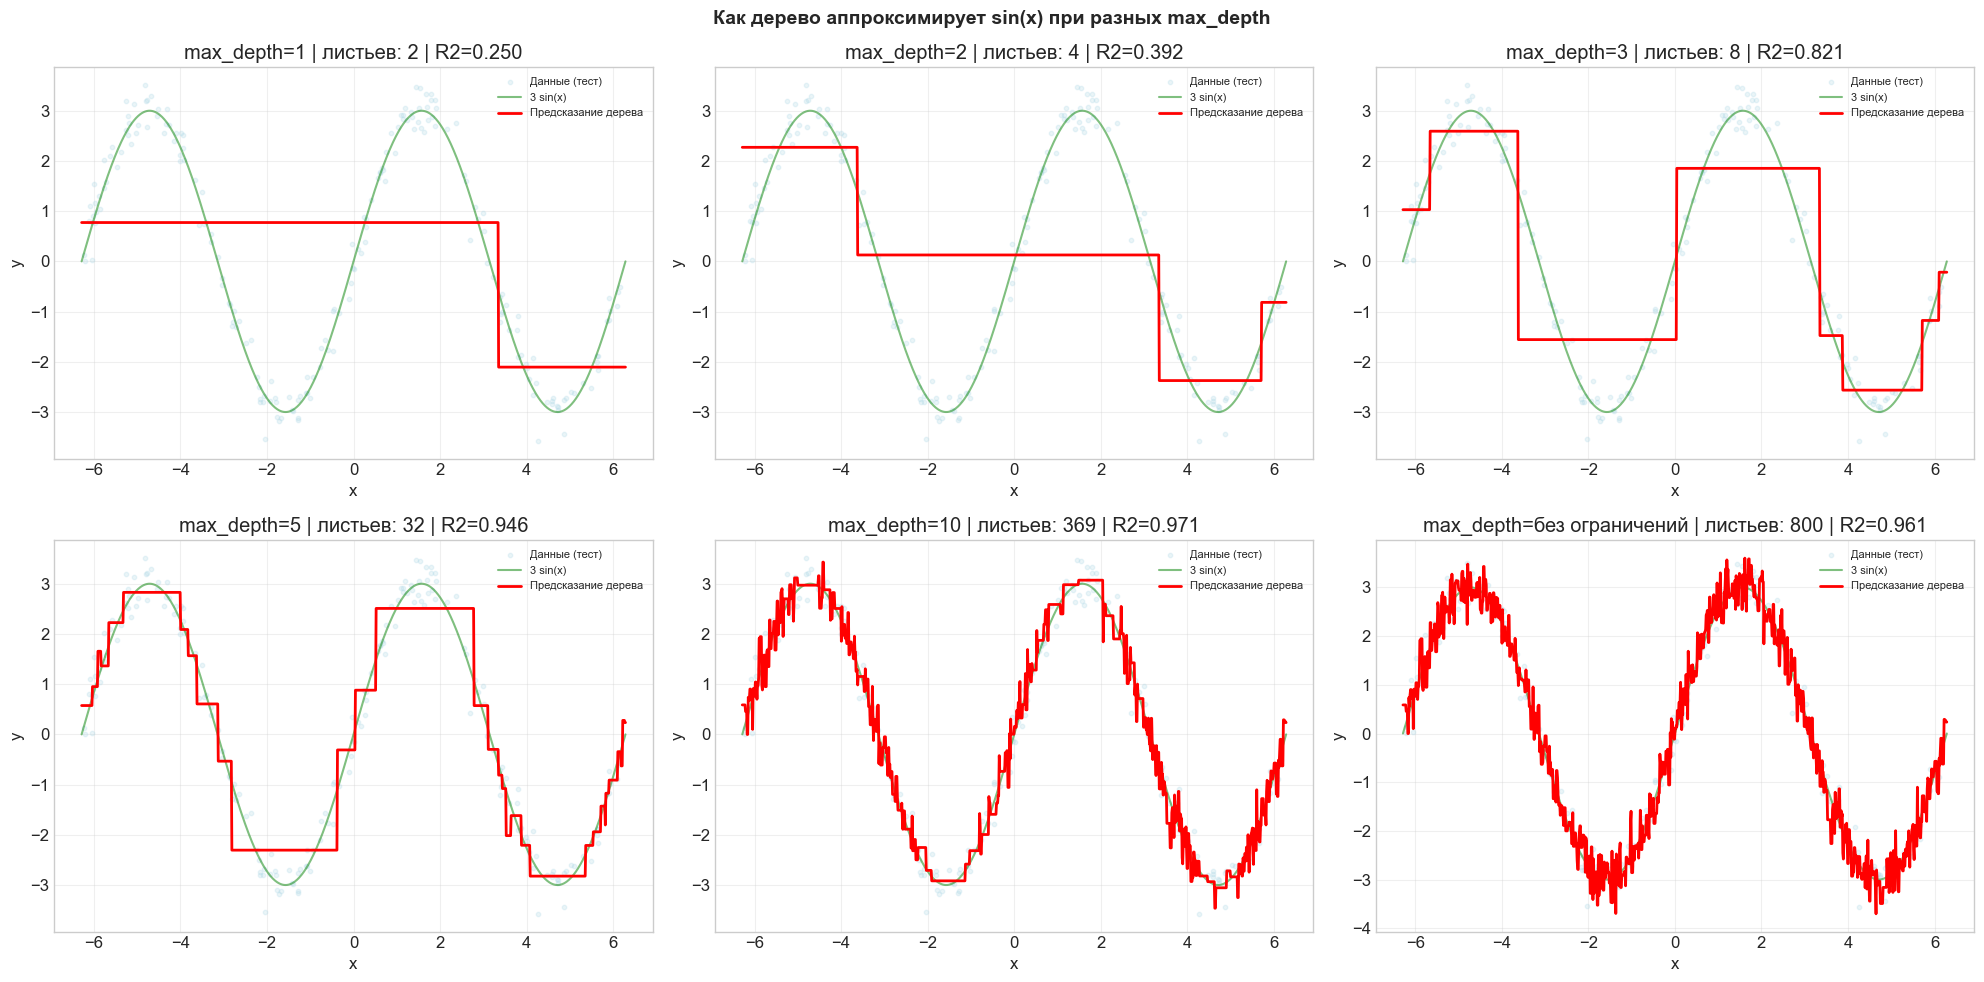

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Как дерево аппроксимирует sin(x) при разных max_depth', fontsize=14, fontweight='bold')

depths_to_show = [1, 2, 3, 5, 10, None]
x_grid = np.linspace(-2*np.pi, 2*np.pi, 1000).reshape(-1, 1)

for idx, d in enumerate(depths_to_show):
    ax = axes[idx // 3, idx % 3]
    
    model_temp = DecisionTreeRegressor(max_depth=d, random_state=42)
    model_temp.fit(X_train_s, y_train_s)
    y_pred_grid = model_temp.predict(x_grid)
    
    # Данные
    ax.scatter(X_test_s['x'], y_test_s, alpha=0.25, s=10, color='lightblue', label='Данные (тест)')
    # Истинная функция
    ax.plot(x_grid, 3 * np.sin(x_grid), 'g-', linewidth=1.5, alpha=0.5, label='3 sin(x)')
    # Предсказание дерева — ступеньки
    ax.plot(x_grid, y_pred_grid, 'r-', linewidth=2, label='Предсказание дерева')
    
    depth_label = str(d) if d else 'без ограничений'
    n_leaves = model_temp.get_n_leaves()
    r2_temp = r2_score(y_test_s, model_temp.predict(X_test_s))
    ax.set_title(f'max_depth={depth_label} | листьев: {n_leaves} | R2={r2_temp:.3f}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
